In [1]:
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr, weightedtau
from sklearn.metrics import r2_score, roc_auc_score, ndcg_score, root_mean_squared_error

sns.set_style('whitegrid')

In [2]:
MODEL_DIR = "results/LORO_sweep"
model_dirs = sorted(
    d for d in os.listdir(MODEL_DIR) if (os.path.isdir(os.path.join(MODEL_DIR, d)) and os.path.exists(f'{MODEL_DIR}/{d}/ChemBERTa-77M-MTR/val_pred.csv'))
)
print(model_dirs)
print(len(model_dirs))

dfs = []
for model_dir in model_dirs:
    dfs.append(pd.read_csv(f'results/LORO_sweep/{model_dir}/ChemBERTa-77M-MTR/val_pred.csv'))
df = pd.concat(dfs, ignore_index=True)
display(df)
print(len(df))

['AgOr1', 'AgOr10', 'AgOr11', 'AgOr12', 'AgOr13', 'AgOr15', 'AgOr16', 'AgOr18', 'AgOr2', 'AgOr20', 'AgOr21', 'AgOr23', 'AgOr25', 'AgOr26', 'AgOr27', 'AgOr3', 'AgOr30', 'AgOr31', 'AgOr32', 'AgOr33', 'AgOr35', 'AgOr38', 'AgOr39', 'AgOr4', 'AgOr41', 'AgOr42', 'AgOr43', 'AgOr44', 'AgOr45', 'AgOr46', 'AgOr48', 'AgOr5', 'AgOr50', 'AgOr53', 'AgOr54', 'AgOr56', 'AgOr57', 'AgOr59', 'AgOr6', 'AgOr61', 'AgOr63', 'AgOr64', 'AgOr65', 'AgOr66', 'AgOr67', 'AgOr73', 'AgOr75', 'AgOr76', 'AgOr8', 'AgOr9']
50


,RECEPTOR,odorant,SMILES,output,Protein sequence,prediction
0,AgOr1,ammonia,N,-0.361859,MKLNKLNPRWDAYDRRDSFWLQLLCLKYLGLWPPEDTDQATRNRYI...,-0.416444
1,AgOr1,putrescine,NCCCCN,-0.510806,MKLNKLNPRWDAYDRRDSFWLQLLCLKYLGLWPPEDTDQATRNRYI...,-0.487866
2,AgOr1,cadaverine,NCCCCCN,-0.485981,MKLNKLNPRWDAYDRRDSFWLQLLCLKYLGLWPPEDTDQATRNRYI...,-0.427639
3,AgOr1,gamma-decalactone,CCCCCCC1CCC(=O)O1,-0.287386,MKLNKLNPRWDAYDRRDSFWLQLLCLKYLGLWPPEDTDQATRNRYI...,-0.374311
4,AgOr1,delta-decalactone,CCCCCC1CCCC(=O)O1,-0.287386,MKLNKLNPRWDAYDRRDSFWLQLLCLKYLGLWPPEDTDQATRNRYI...,-0.420218
...,...,...,...,...,...,...
5495,AgOr9,methyl-octanoate,CCCCCCCC(=O)OC,-0.262561,MFLPSLRMILFIFRMFYAWPDEHLEKSALWWYRAKGVLFRVFFIYL...,-0.038459
5496,AgOr9,heptane,CCCCCCC,-0.411508,MFLPSLRMILFIFRMFYAWPDEHLEKSALWWYRAKGVLFRVFFIYL...,-0.002155
5497,AgOr9,1-chlorododecane,CCCCCCCCCCCCCl,-0.287386,MFLPSLRMILFIFRMFYAWPDEHLEKSALWWYRAKGVLFRVFFIYL...,-0.240337
5498,AgOr9,5α-androst-16-one,C[C@]12CCC(=O)C[C@@H]1CC[C@@H]1[C@@H]2CC[C@]2(...,-0.262561,MFLPSLRMILFIFRMFYAWPDEHLEKSALWWYRAKGVLFRVFFIYL...,-0.268961


5500


5 Count: 25
10 Count: 21


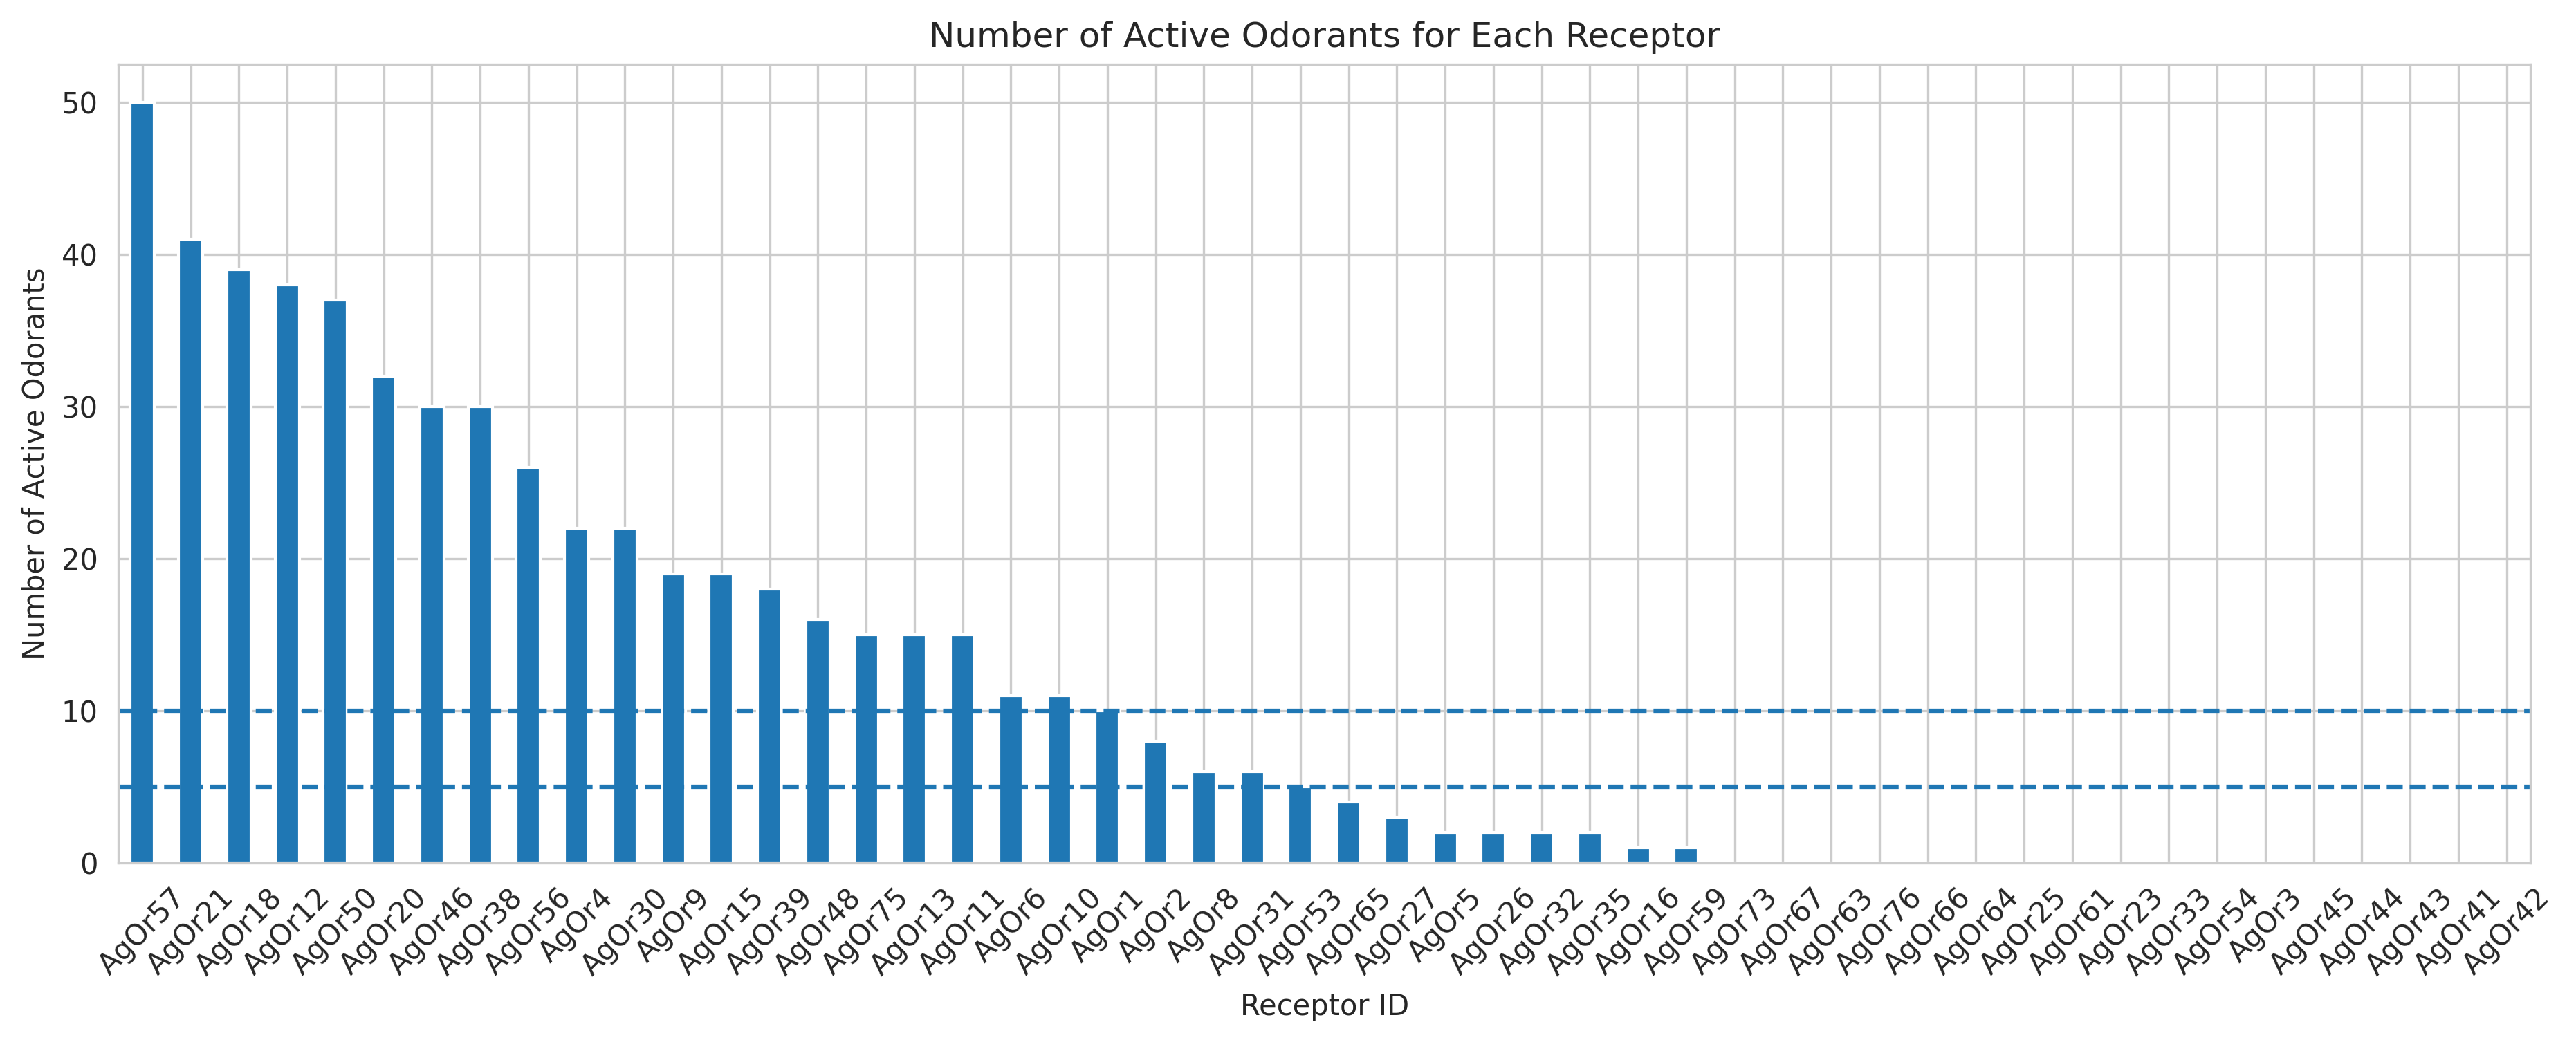

In [3]:
# Count number of actives for each receptors
threshold = 1
active_counts = (df['output'] > threshold).groupby(df['RECEPTOR']).sum()
sorted_active_counts = active_counts.sort_values(ascending=False)

print('5 Count:', (active_counts >= 5).sum())
print('10 Count:', (active_counts >= 10).sum())
fig, ax = plt.subplots(figsize=(15,5), dpi=300)
sorted_active_counts.plot.bar(ax=ax, rot=45)
ax.axhline(y=10, linestyle='--')
ax.axhline(y=5, linestyle='--')
ax.set_ylabel('Number of Active Odorants')
ax.set_xlabel('Receptor ID')
ax.set_title('Number of Active Odorants for Each Receptor')
plt.show()

In [4]:
# Filter by number of actives
min_actives = 10
keep = active_counts[active_counts >= min_actives].index
df_filtered = df[df['RECEPTOR'].isin(keep)].reset_index(drop=True)
receptors_filtered = list(keep)

display(df_filtered)

,RECEPTOR,odorant,SMILES,output,Protein sequence,prediction
0,AgOr1,ammonia,N,-0.361859,MKLNKLNPRWDAYDRRDSFWLQLLCLKYLGLWPPEDTDQATRNRYI...,-0.416444
1,AgOr1,putrescine,NCCCCN,-0.510806,MKLNKLNPRWDAYDRRDSFWLQLLCLKYLGLWPPEDTDQATRNRYI...,-0.487866
2,AgOr1,cadaverine,NCCCCCN,-0.485981,MKLNKLNPRWDAYDRRDSFWLQLLCLKYLGLWPPEDTDQATRNRYI...,-0.427639
3,AgOr1,gamma-decalactone,CCCCCCC1CCC(=O)O1,-0.287386,MKLNKLNPRWDAYDRRDSFWLQLLCLKYLGLWPPEDTDQATRNRYI...,-0.374311
4,AgOr1,delta-decalactone,CCCCCC1CCCC(=O)O1,-0.287386,MKLNKLNPRWDAYDRRDSFWLQLLCLKYLGLWPPEDTDQATRNRYI...,-0.420218
...,...,...,...,...,...,...
2305,AgOr9,methyl-octanoate,CCCCCCCC(=O)OC,-0.262561,MFLPSLRMILFIFRMFYAWPDEHLEKSALWWYRAKGVLFRVFFIYL...,-0.038459
2306,AgOr9,heptane,CCCCCCC,-0.411508,MFLPSLRMILFIFRMFYAWPDEHLEKSALWWYRAKGVLFRVFFIYL...,-0.002155
2307,AgOr9,1-chlorododecane,CCCCCCCCCCCCCl,-0.287386,MFLPSLRMILFIFRMFYAWPDEHLEKSALWWYRAKGVLFRVFFIYL...,-0.240337
2308,AgOr9,5α-androst-16-one,C[C@]12CCC(=O)C[C@@H]1CC[C@@H]1[C@@H]2CC[C@]2(...,-0.262561,MFLPSLRMILFIFRMFYAWPDEHLEKSALWWYRAKGVLFRVFFIYL...,-0.268961


/scratch/6832757.1.p-int/ipykernel_1786361/1746308255.py:3: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: root_mean_squared_error(g['output'], g['prediction']))


<Axes: xlabel='RECEPTOR'>

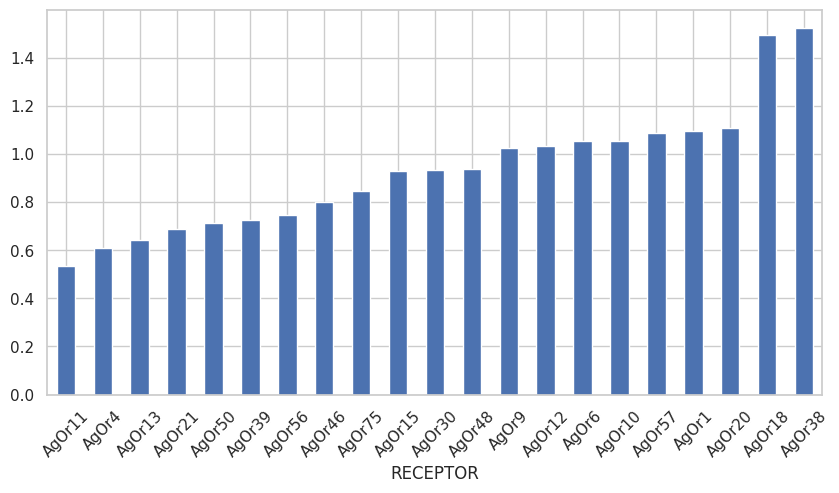

In [32]:
# Metrics: RMSE, R^2, 
receptor_rmse = (df_filtered.groupby('RECEPTOR')
                    .apply(lambda g: root_mean_squared_error(g['output'], g['prediction']))
                    .sort_values())

plt.figure(figsize=(10, 5))
receptor_rmse.plot.bar(rot=45)

# result = {'RMSE': {}, 'R2': {}}
# for model in model_dirs:
#     sub_df = df[df['RECEPTOR'] == model]
#     result[model[4:]] = root_mean_squared_error(sub_df['output'], sub_df['prediction'])

#     result[model[4:]] = r2_score(sub_df['output'], sub_df['prediction'])

#     result[model[4:]] = pearsonr(sub_df['output'], sub_df['prediction'])[0]

#     result[model[4:]] = spearmanr(sub_df['output'], sub_df['prediction'])[0]

#     result[model[4:]] = roc_auc_score(sub_df['output'] >= 2, sub_df['prediction'])


# result = dict(sorted(result.items(), key=lambda kv: kv[1], reverse=True))
# fig, ax = plt.subplots(figsize=(10,5))
# ax.bar(result.keys(), result.values(), )
###ax.set_ylim(-1, 1)

# Spearman on Active

AgOr1
AgOr10
AgOr11
AgOr12
AgOr13
AgOr15
AgOr18
AgOr2
AgOr20
AgOr21
AgOr30
AgOr38
AgOr4
AgOr46
AgOr48


<BarContainer object of 15 artists>

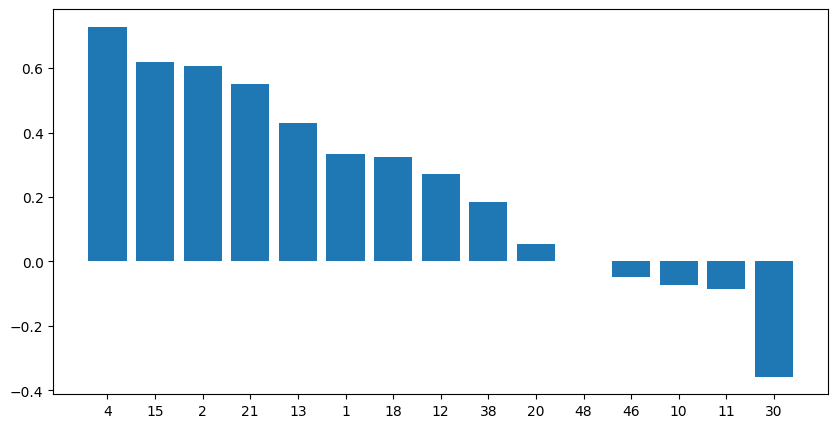

In [28]:
result = {}
for model in model_dirs:
    sub_df = df[df['RECEPTOR'] == model]
    if (sub_df['output'] > 2).sum() > 5:
        print(model)
        active = sub_df[sub_df['output'] > 2]
        #display(active)
        result[model[4:]] = spearmanr(active['output'], active['prediction'])[0]

result = dict(sorted(result.items(), key=lambda kv: kv[1], reverse=True))
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(result.keys(), result.values(), )

<BarContainer object of 21 artists>

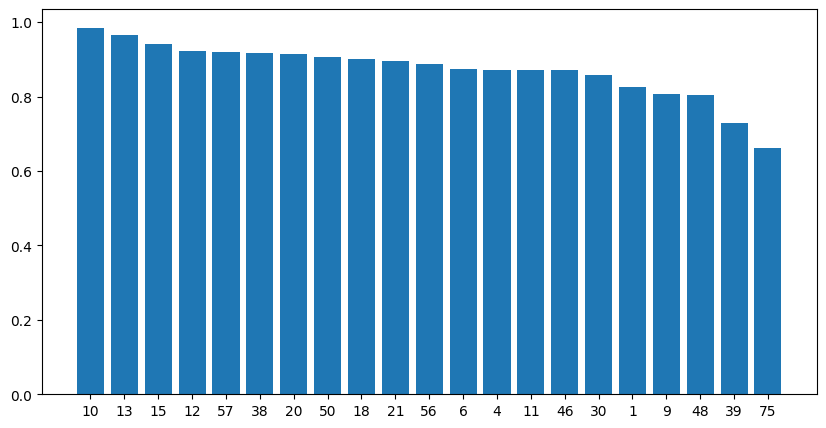

In [6]:
result = {}
for model in model_dirs:
    sub_df = df[df['RECEPTOR'] == model]
    result[model[4:]] = roc_auc_score(sub_df['output'] >= 2, sub_df['prediction'])

result = dict(sorted(result.items(), key=lambda kv: kv[1], reverse=True))
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(result.keys(), result.values(), )

# NDCG

<BarContainer object of 21 artists>

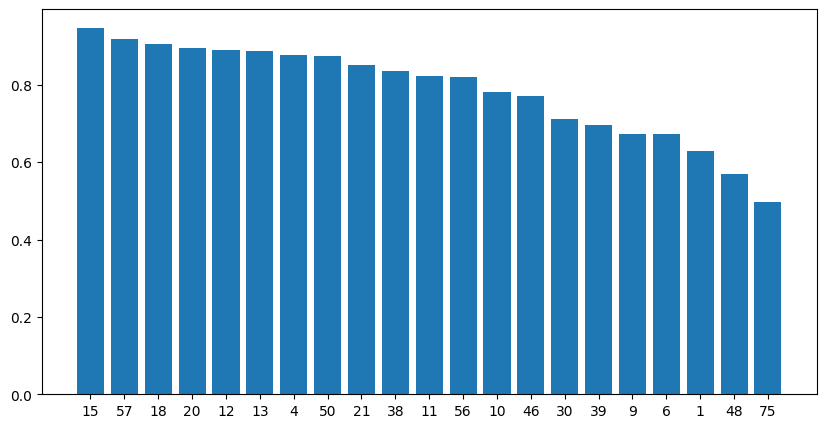

In [70]:
def ndcg_relu(y_true, y_pred, k=None):
    """NDCG with gain = relu(true z). Returns [0, 1]; 1 = high responders on top.
    k=None uses the full list; set k to focus on the very top."""
    gains  = np.clip(np.asarray(y_true), 0, None)[None, :]
    scores = np.asarray(y_pred)[None, :]
    return ndcg_score(gains, scores, k=k)

result = {}
for model in model_dirs:
    sub_df = df[df['RECEPTOR'] == model]
    result[model[4:]] = ndcg_relu(sub_df['output'], sub_df['prediction'])

result = dict(sorted(result.items(), key=lambda kv: kv[1], reverse=True))
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(result.keys(), result.values(), )

(0.0, 1.0)

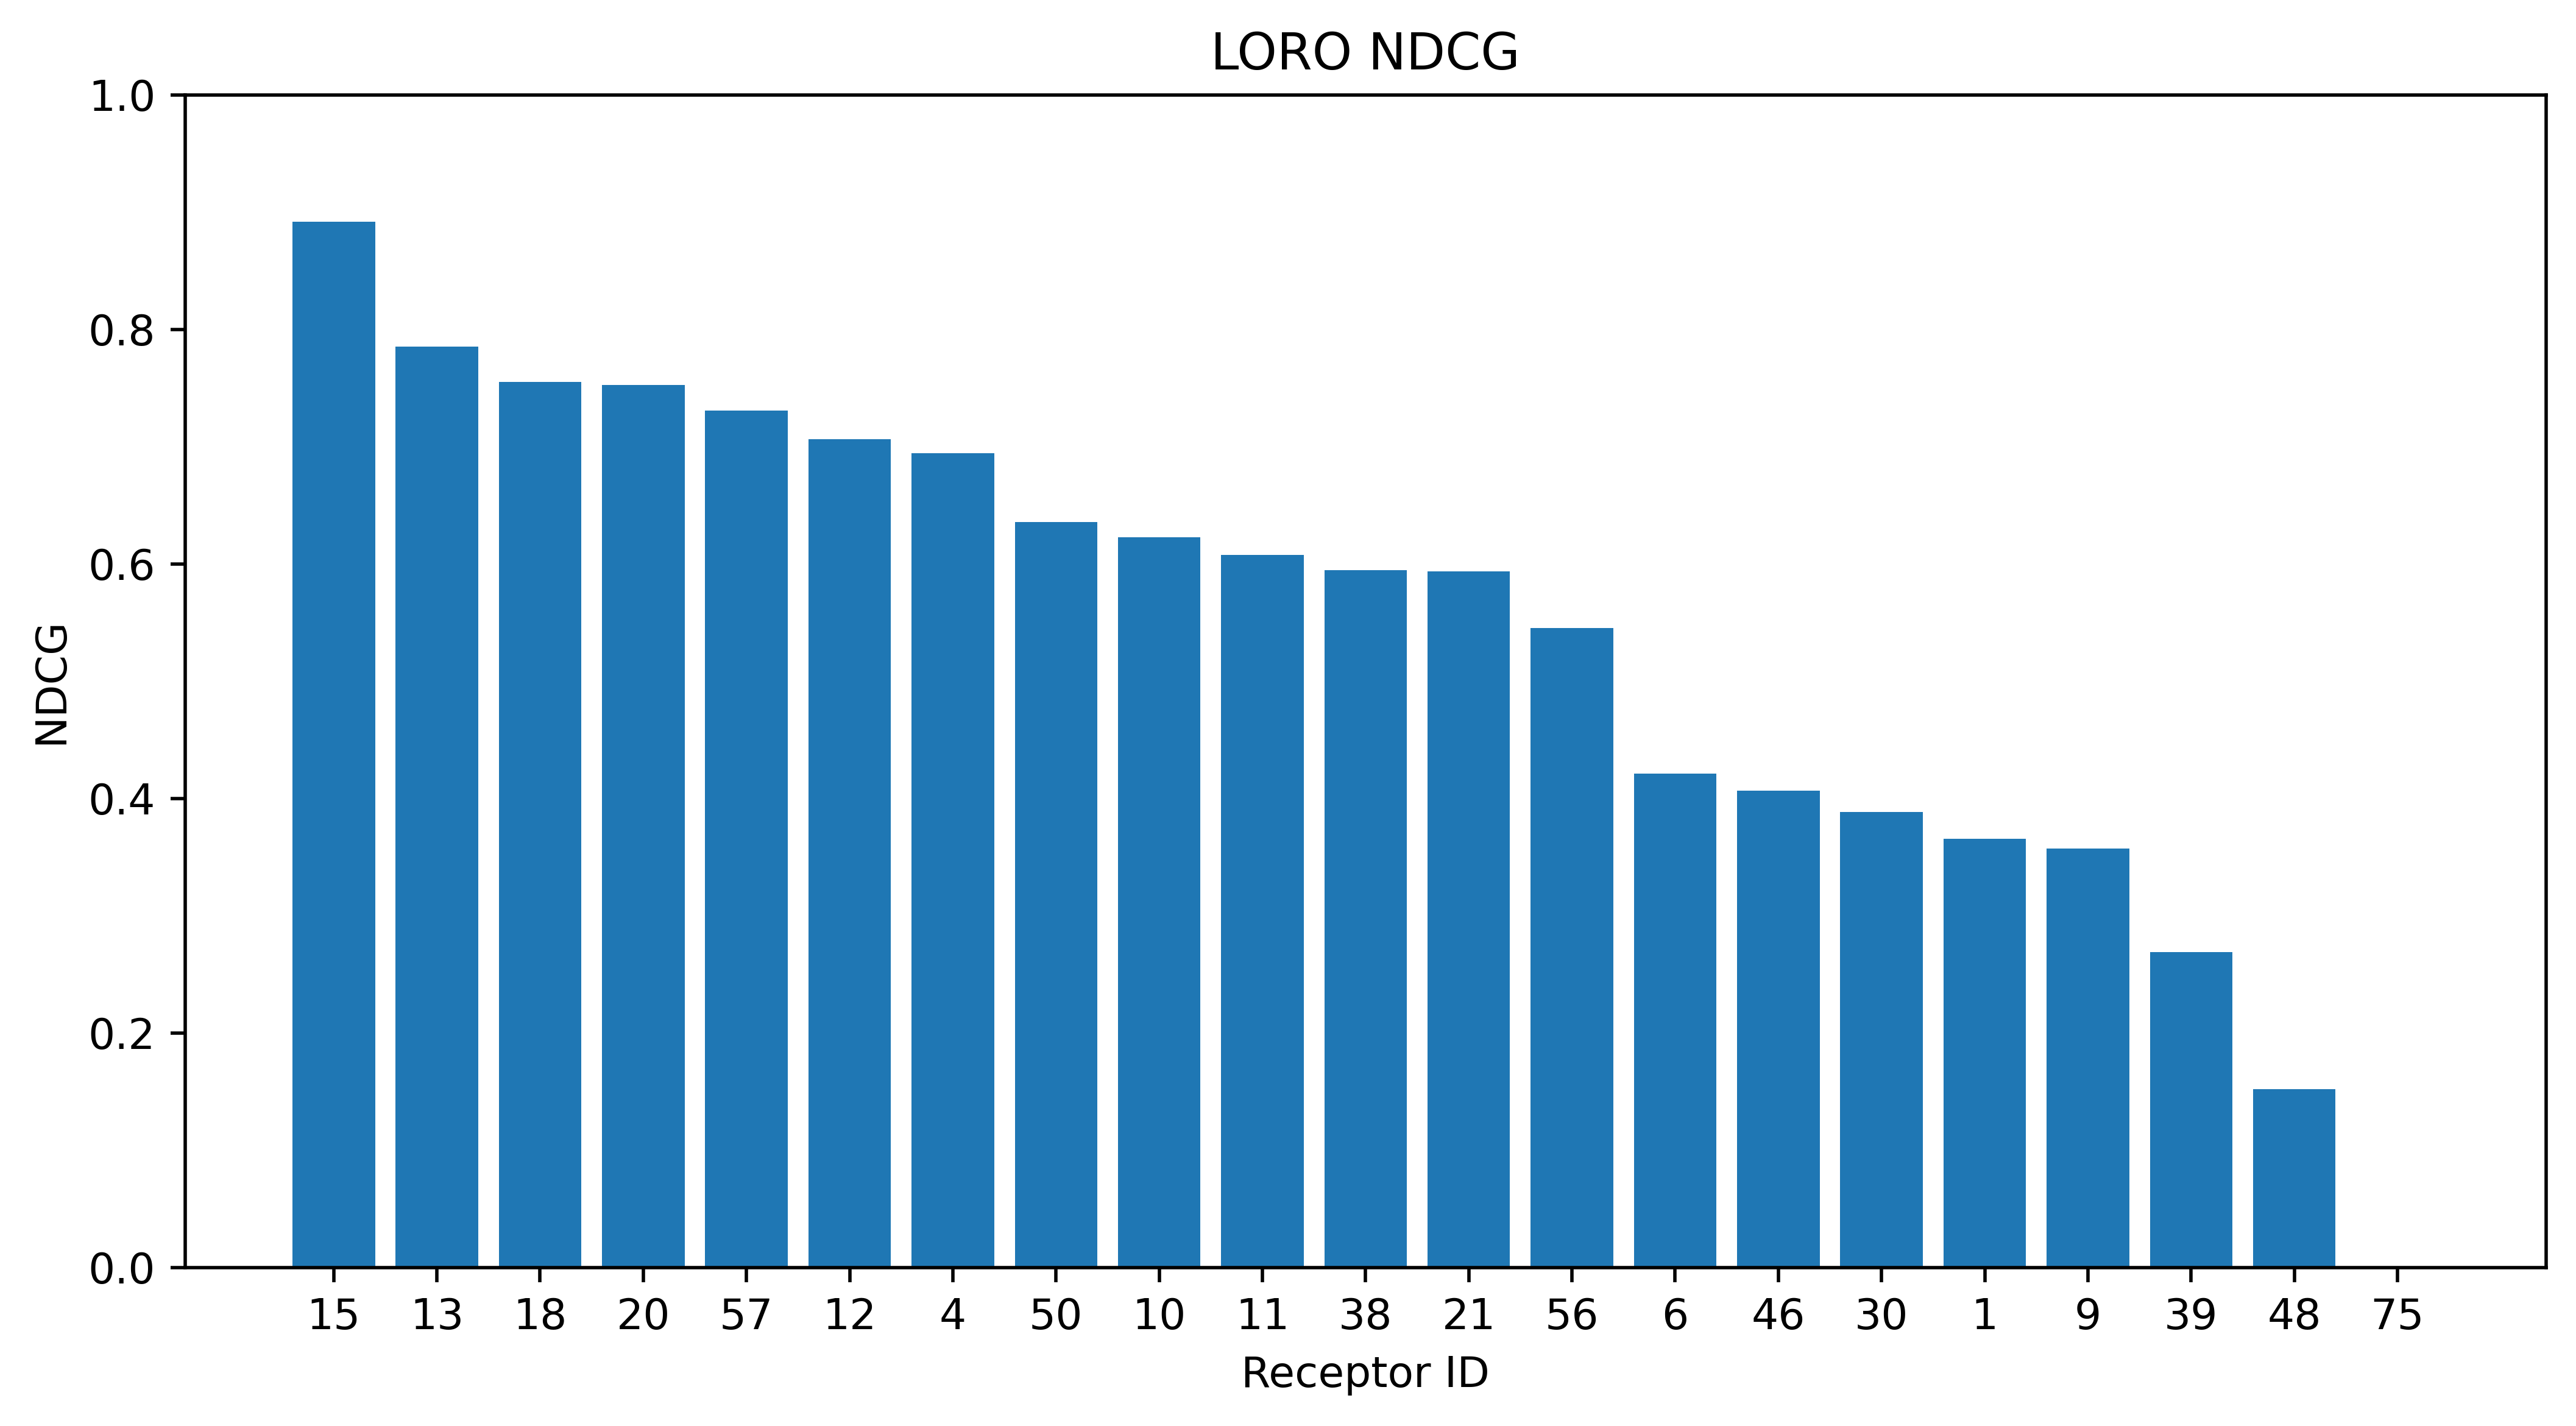

In [22]:
def ndcg_comparable(y_true, y_pred, k=None, n_perm=1000, seed=0):
    """NDCG normalized against a per-receptor random baseline -> comparable across receptors.
       skill : (ndcg - null_mean)/(1 - null_mean)   0=random, 1=perfect
       z     : (ndcg - null_mean)/null_std          SDs above chance (signal-vs-noise)
       pctile: fraction of random permutations below observed (a 1-sided p = 1-pctile)"""
    gains  = np.clip(np.asarray(y_true), 0, None)[None, :]
    scores = np.asarray(y_pred)
    obs = ndcg_score(gains, scores[None, :], k=k)
    rng = np.random.default_rng(seed)
    null = np.array([ndcg_score(gains, rng.permutation(scores)[None, :], k=k)
                     for _ in range(n_perm)])
    m, s = null.mean(), null.std()
    return dict(ndcg=obs,
                skill = (obs - m)/(1 - m) if m < 1 else np.nan,
                z     = (obs - m)/s if s > 0 else np.nan,
                pctile= (null < obs).mean(),
                null_mean=m, null_std=s)

result = {}
for model in model_dirs:
    sub_df = df[df['RECEPTOR'] == model]
    result[model[4:]] = ndcg_comparable(sub_df['output'], sub_df['prediction'])['skill']

result_sorted = dict(sorted(result.items(), key=lambda kv: kv[1], reverse=True))
fig, ax = plt.subplots(figsize=(10,5), dpi=500)
ax.bar(result_sorted.keys(), result_sorted.values(), )
ax.set_ylabel('NDCG')
ax.set_xlabel('Receptor ID')
ax.set_title('LORO NDCG')
ax.set_ylim(0, 1.0)

Text(0, 0.5, 'NDCG')

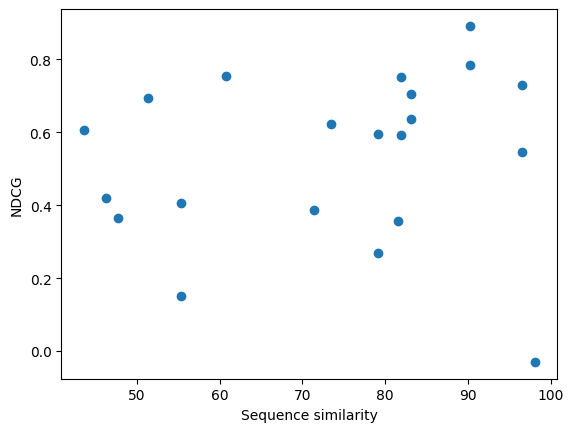

In [23]:
similarity = [47.77777777777778,  73.42105263157895, 43.619489559164734, 83.16582914572864, 90.18087855297158, 90.18087855297158, 60.80402010050251, 81.90954773869346, 81.90954773869346, 71.35416666666667, 79.16666666666667, 79.16666666666667, 51.37844611528822, 55.31400966183575, 55.31400966183575, 83.16582914572864, 96.5, 96.5, 46.25850340136054, 98.05352798053528, 81.5909090909091]
plt.scatter(similarity, result.values())
plt.xlabel('Sequence similarity')
plt.ylabel('NDCG')

# Weighted Kendall

<BarContainer object of 21 artists>

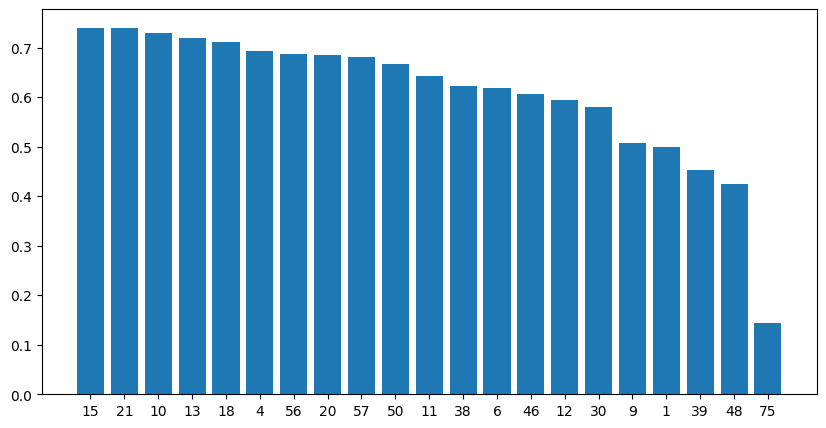

In [60]:
def weighted_kendall(y_true, y_pred):
    """Kendall's tau where disagreements among high true responders count most.
    Returns tau in [-1, 1]; 0 = chance, 1 = perfect top-emphasized ordering."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    rank = np.argsort(np.argsort(-y_true))   # 0 = highest true value -> most weight
    tau, _ = weightedtau(y_pred, y_true, rank=rank)
    return tau
result = {}
for model in model_dirs:
    sub_df = df[df['RECEPTOR'] == model]
    result[model[4:]] = weighted_kendall(sub_df['output'], sub_df['prediction'])

result = dict(sorted(result.items(), key=lambda kv: kv[1], reverse=True))
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(result.keys(), result.values(), )

# Topk overlap

/scratch/6870247.1.p-int/ipykernel_2226038/987001439.py:11: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: topk_overlap(g['output'], g['prediction'], k=10))


0.38095238095238093


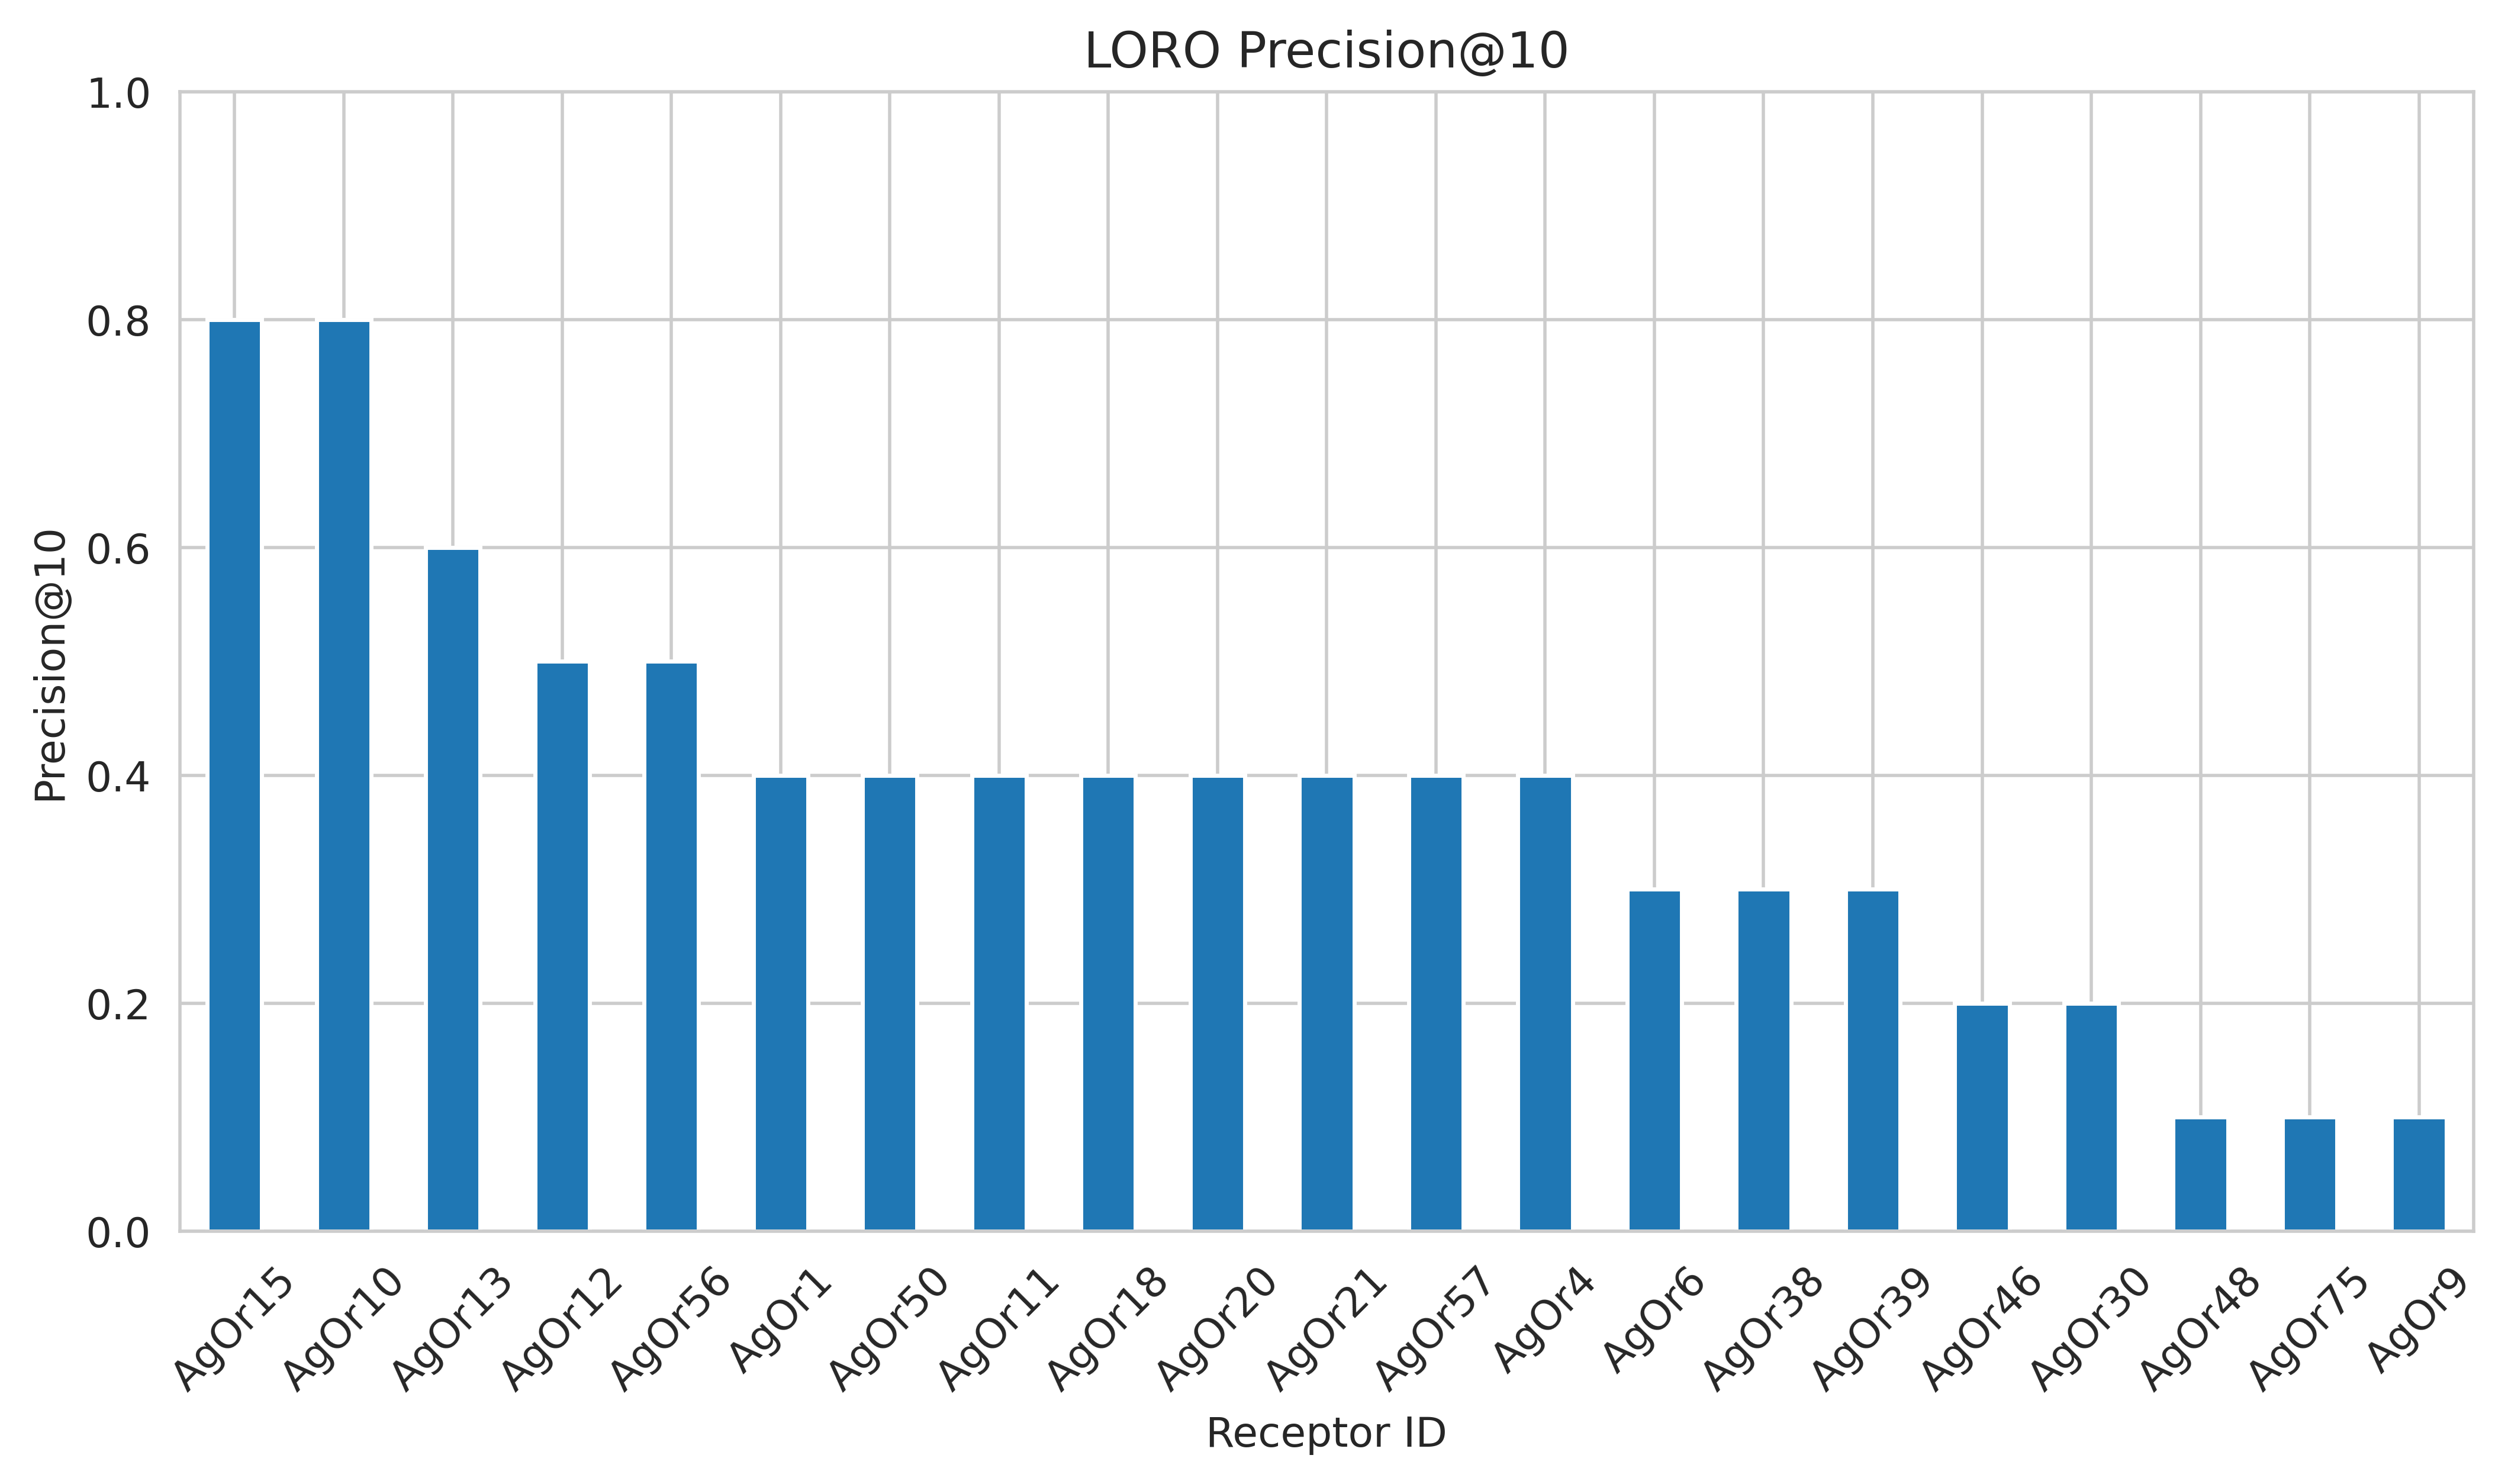

In [11]:
def topk_overlap(y_true, y_pred, k=10):
    """Fraction of the true top-k that land in the predicted top-k (ignores order).
    Robust to ground-truth noise among near-tied top responders."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    k = min(k, len(y_true))
    true_top = set(np.argsort(y_true)[::-1][:k])
    pred_top = set(np.argsort(y_pred)[::-1][:k])
    return len(true_top & pred_top) / k

topk = (df_filtered.groupby('RECEPTOR')
                .apply(lambda g: topk_overlap(g['output'], g['prediction'], k=10))
                .sort_values(ascending=False))

print(topk.mean())

fig, ax = plt.subplots(figsize=(10,5), dpi=500)
plt.grid(axis='y')
topk.plot.bar(ax=ax, rot=45)
ax.set_ylabel('Precision@10')
ax.set_xlabel('Receptor ID')
ax.set_title('LORO Precision@10')
ax.set_ylim(0, 1.0)

plt.show()


/scratch/6832757.1.p-int/ipykernel_1901577/4185789655.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: topk_overlap(g['output'], g['prediction'], k=(g['output'] > 1).sum()))


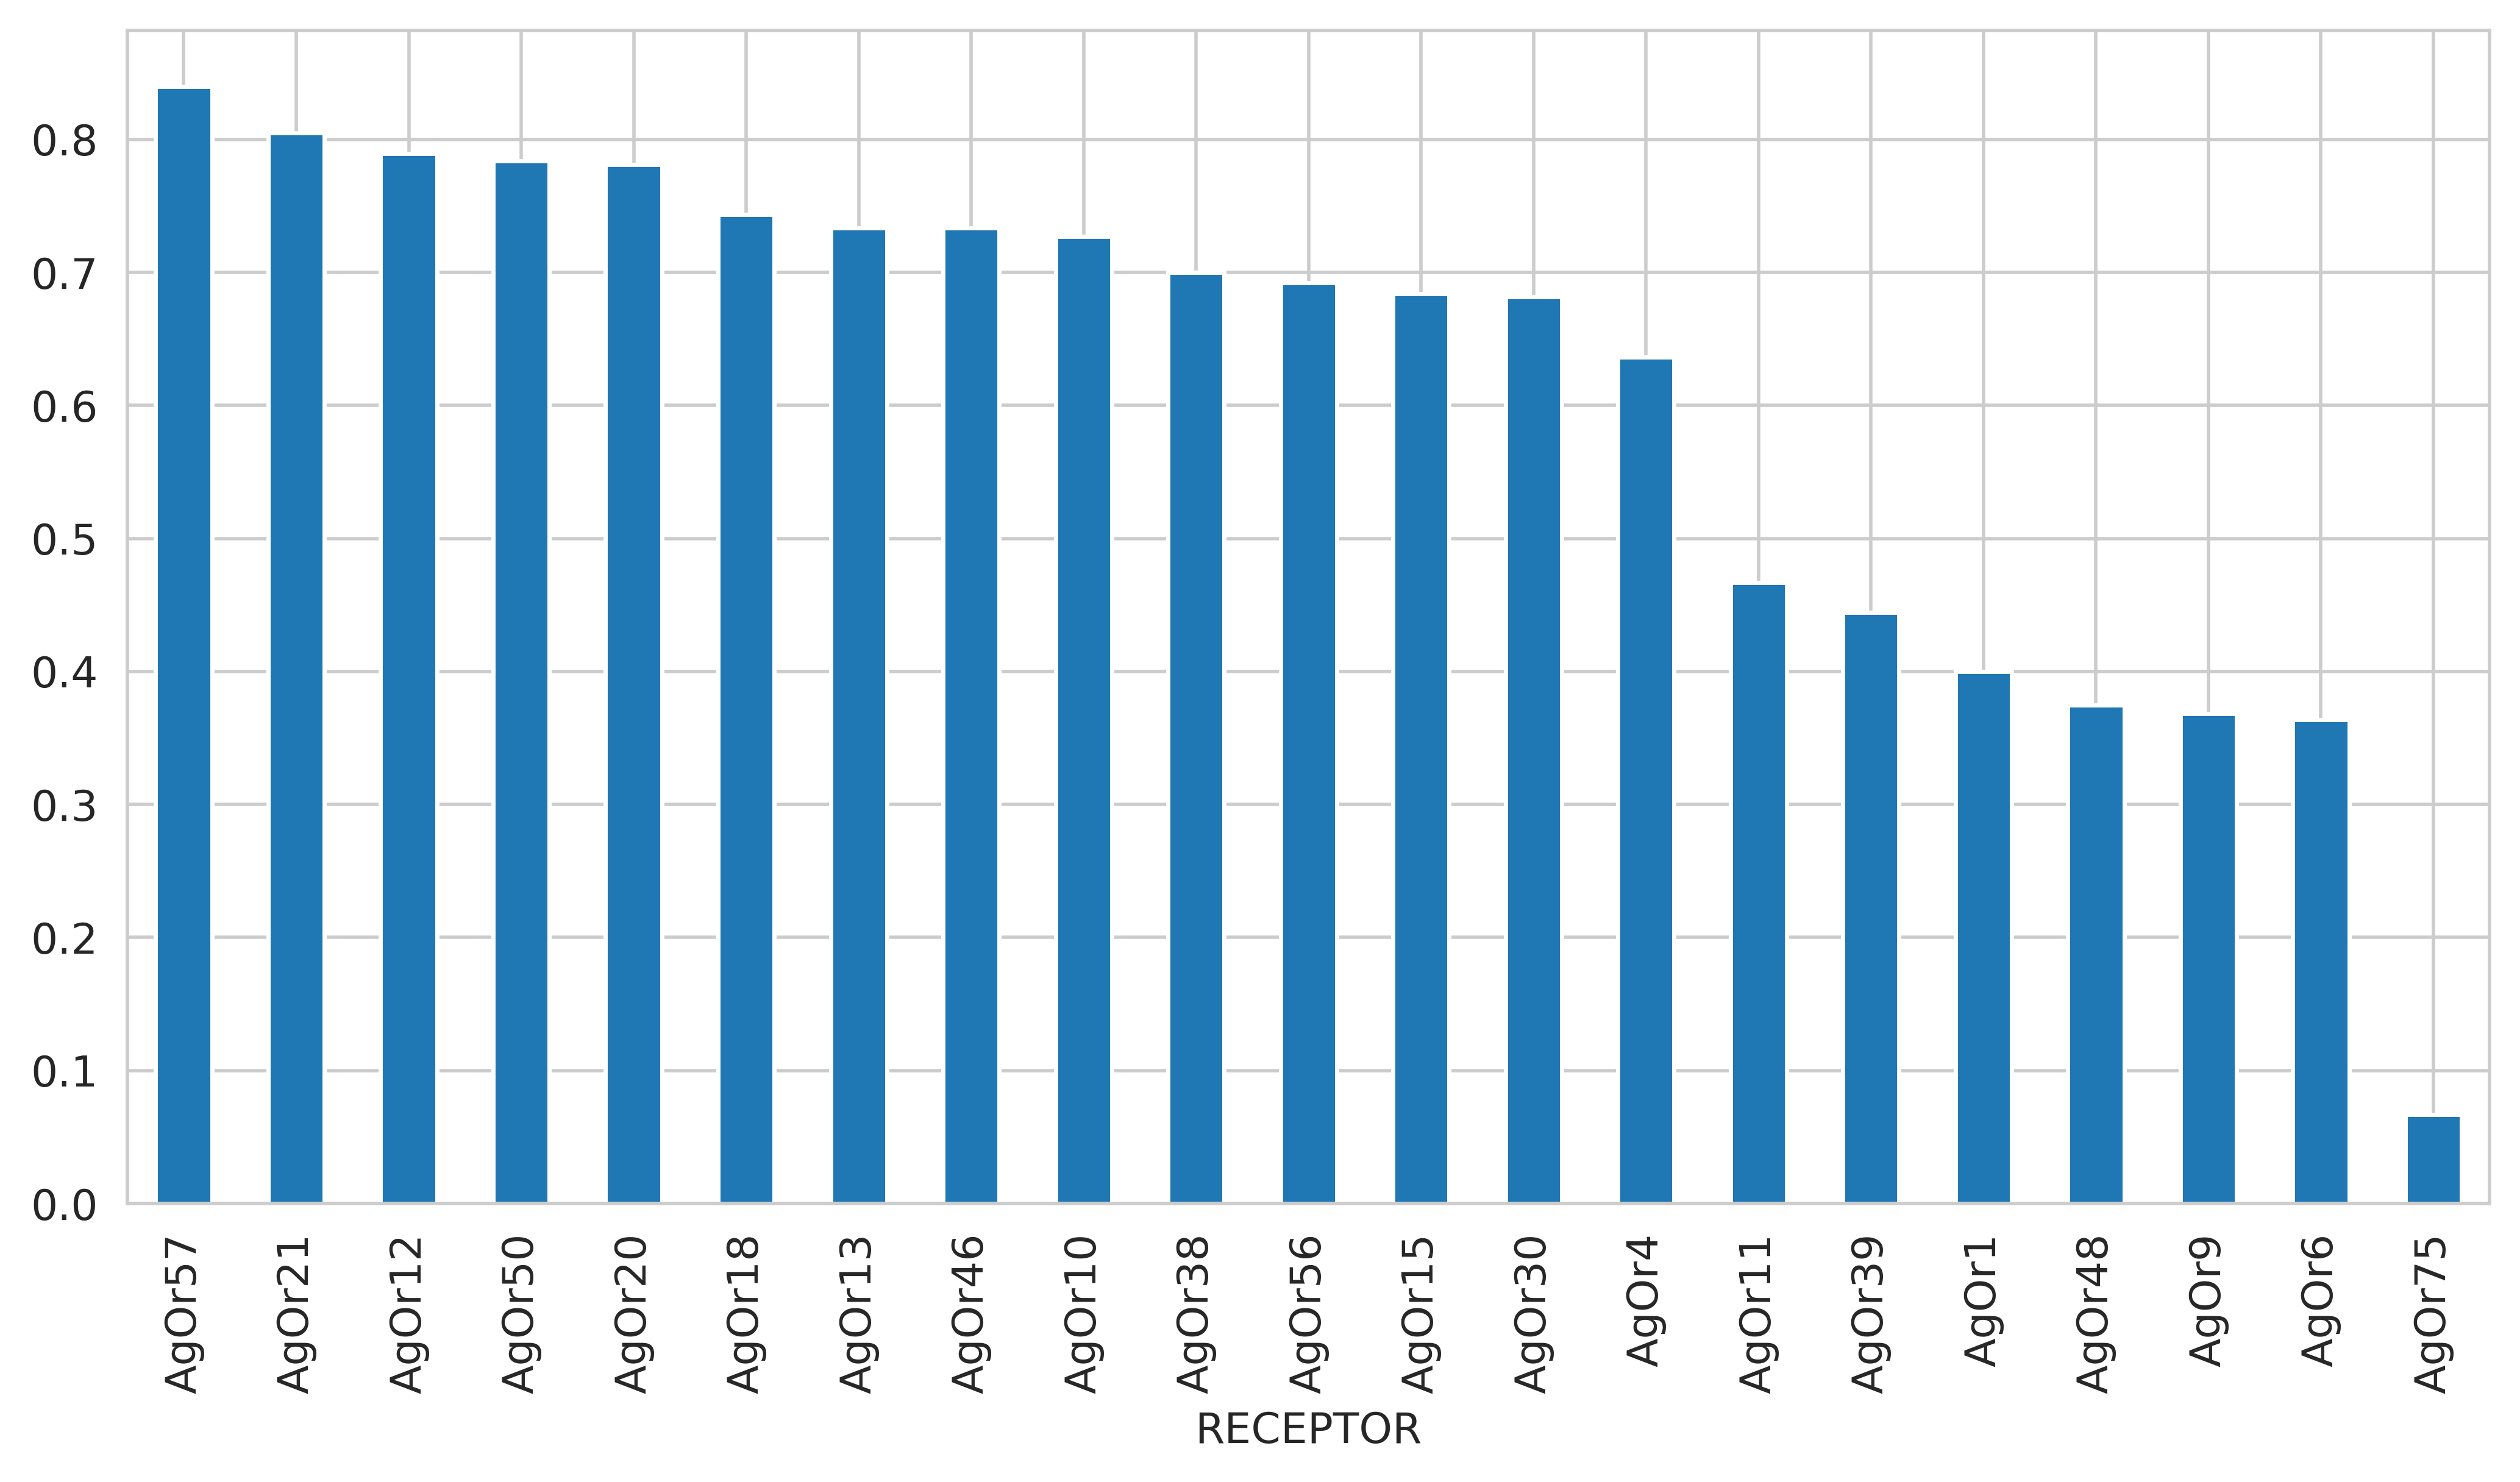

In [8]:
r_precision = (df_filtered.groupby('RECEPTOR')
                .apply(lambda g: topk_overlap(g['output'], g['prediction'], k=(g['output'] > 1).sum()))
                .sort_values(ascending=False))
plt.figure(figsize=(10,5), dpi=500)
r_precision.plot.bar()
plt.show()

{'1': np.float64(4.0740740740740735), '10': np.float64(11.458333333333334), '11': np.float64(3.0555555555555554), '12': np.float64(4.4), '13': np.float64(6.875), '15': np.float64(7.333333333333334), '18': np.float64(4.166666666666667), '20': np.float64(4.166666666666667), '21': np.float64(5.238095238095238), '30': np.float64(1.8333333333333333), '38': np.float64(3.333333333333333), '39': np.float64(4.583333333333333), '4': np.float64(6.111111111111111), '46': np.float64(2.2916666666666665), '48': np.float64(0.0), '50': np.float64(5.6410256410256405), '56': np.float64(2.4444444444444446), '57': np.float64(3.548387096774194), '6': np.float64(5.238095238095238), '75': np.float64(3.6666666666666665), '9': np.float64(1.8333333333333333)}


<BarContainer object of 21 artists>

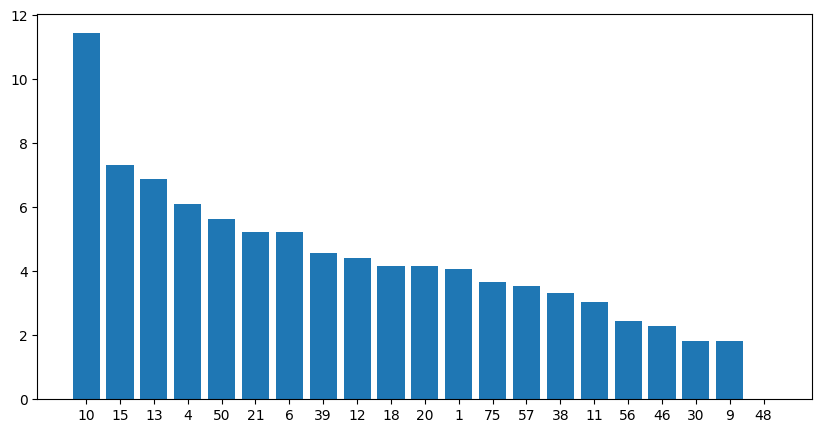

In [63]:
def enrichment_at_k(y_true, y_pred, tau=2.0, frac=0.05):
    """Fold-enrichment of true actives (z>=tau) in the top `frac` of predictions.
    e.g. 6.0 = actives are 6x more concentrated in the top slice than at random."""
    y_true, y_pred = np.asarray(y_true), np.asarray(y_pred)
    active = (y_true >= tau).astype(float)
    n_top  = max(1, int(np.ceil(frac * len(y_true))))
    top    = np.argsort(y_pred)[::-1][:n_top]
    base   = active.mean()
    return np.nan if base == 0 else active[top].mean() / base
result = {}
for model in model_dirs:
    sub_df = df[df['RECEPTOR'] == model]
    result[model[4:]] = enrichment_at_k(sub_df['output'], sub_df['prediction'])
print(result)
result = dict(sorted(result.items(), key=lambda kv: kv[1], reverse=True))
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(result.keys(), result.values(), )

# Other Analysis

SignificanceResult(statistic=np.float64(0.5541248441106376), pvalue=np.float64(3.387425280323305e-10))


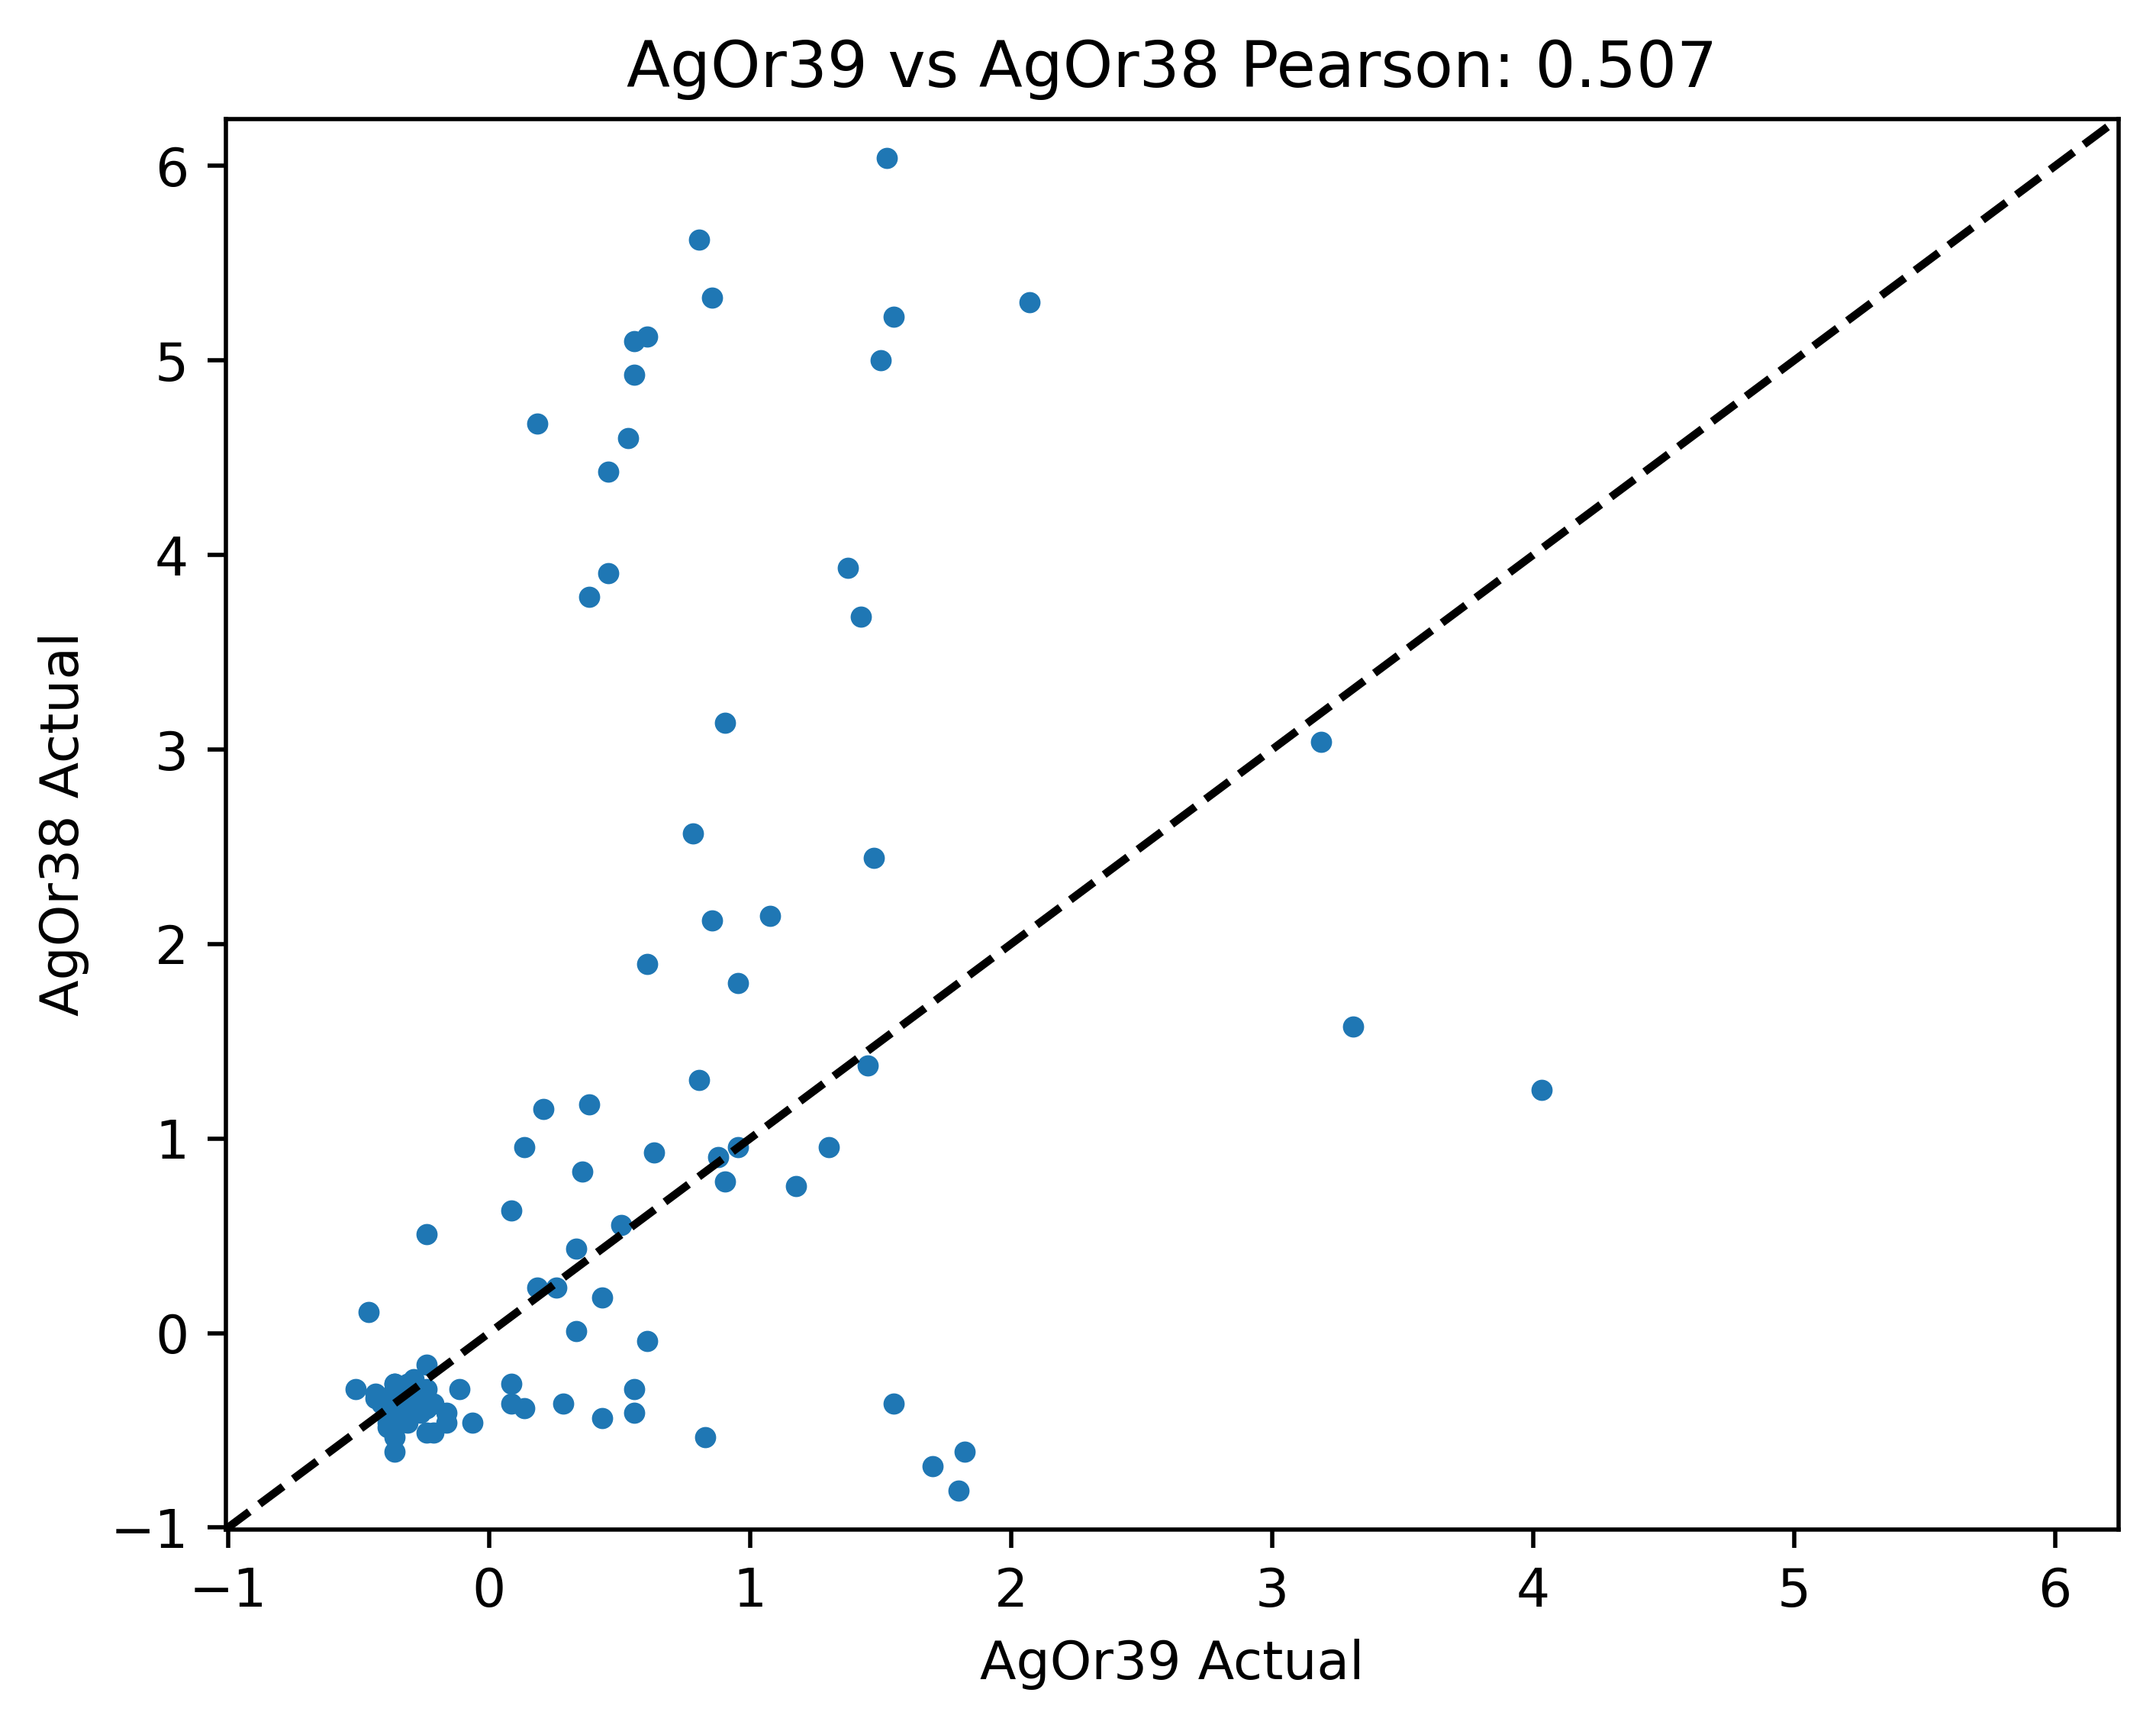

PearsonRResult(statistic=np.float64(0.5065608494431285), pvalue=np.float64(1.6394829036795866e-08))


In [72]:
raw_df = pd.read_csv('data/CC/raw/CC_reformat_z.csv')
receptor1 = 'AgOr39'
receptor2 = 'AgOr38'

receptor1_df = raw_df[raw_df['RECEPTOR'] == receptor1]
receptor2_df = raw_df[raw_df['RECEPTOR'] == receptor2]
plt.figure(dpi=500)
plt.scatter(receptor1_df['output'], receptor2_df['output'], marker='.')
max_val = max(np.max(receptor1_df['output']), np.max(receptor2_df['output'])) + 0.2
min_val = min(np.min(receptor1_df['output']), np.min(receptor2_df['output'])) - 0.2
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.axline((0, 0), slope=1, color='k', linestyle='--')
plt.xlabel(f'{receptor1} Actual')
plt.ylabel(f'{receptor2} Actual')
corr = pearsonr(raw_df[raw_df['RECEPTOR'] == receptor1]['output'], raw_df[raw_df['RECEPTOR'] == receptor2]['output'])
print(spearmanr(receptor1_df['output'], receptor2_df['output']))
plt.title(f'{receptor1} vs {receptor2} Pearson: {corr[0]:.3f}')
plt.show()
print(corr)

In [25]:
corrs = np.zeros((21, 21))
names = df_filtered['RECEPTOR'].unique()
print(len(names))
for i in range(21):
    for j in range(21):
        r1 = df_filtered[df_filtered['RECEPTOR'] == names[i]]
        r2 = df_filtered[df_filtered['RECEPTOR'] == names[j]]
        #corrs[i, j] = pearsonr(r1['output'], r2['output'])[0]
        #corrs[i, j] = spearmanr(r1['output'], r2['output'])[0]
        corrs[i, j] = topk_overlap(r1['output'], r2['output'])



21


In [48]:
names

array(['AgOr1', 'AgOr10', 'AgOr11', 'AgOr12', 'AgOr13', 'AgOr15',
       'AgOr18', 'AgOr20', 'AgOr21', 'AgOr30', 'AgOr38', 'AgOr39',
       'AgOr4', 'AgOr46', 'AgOr48', 'AgOr50', 'AgOr56', 'AgOr57', 'AgOr6',
       'AgOr75', 'AgOr9'], dtype=object)

In [49]:
ind = 2
print(names[ind])
np.delete(corrs[ind], ind).max()
new_names = np.delete(names, ind)
print(new_names[np.delete(corrs[ind], ind).argmax()])

AgOr11
AgOr21


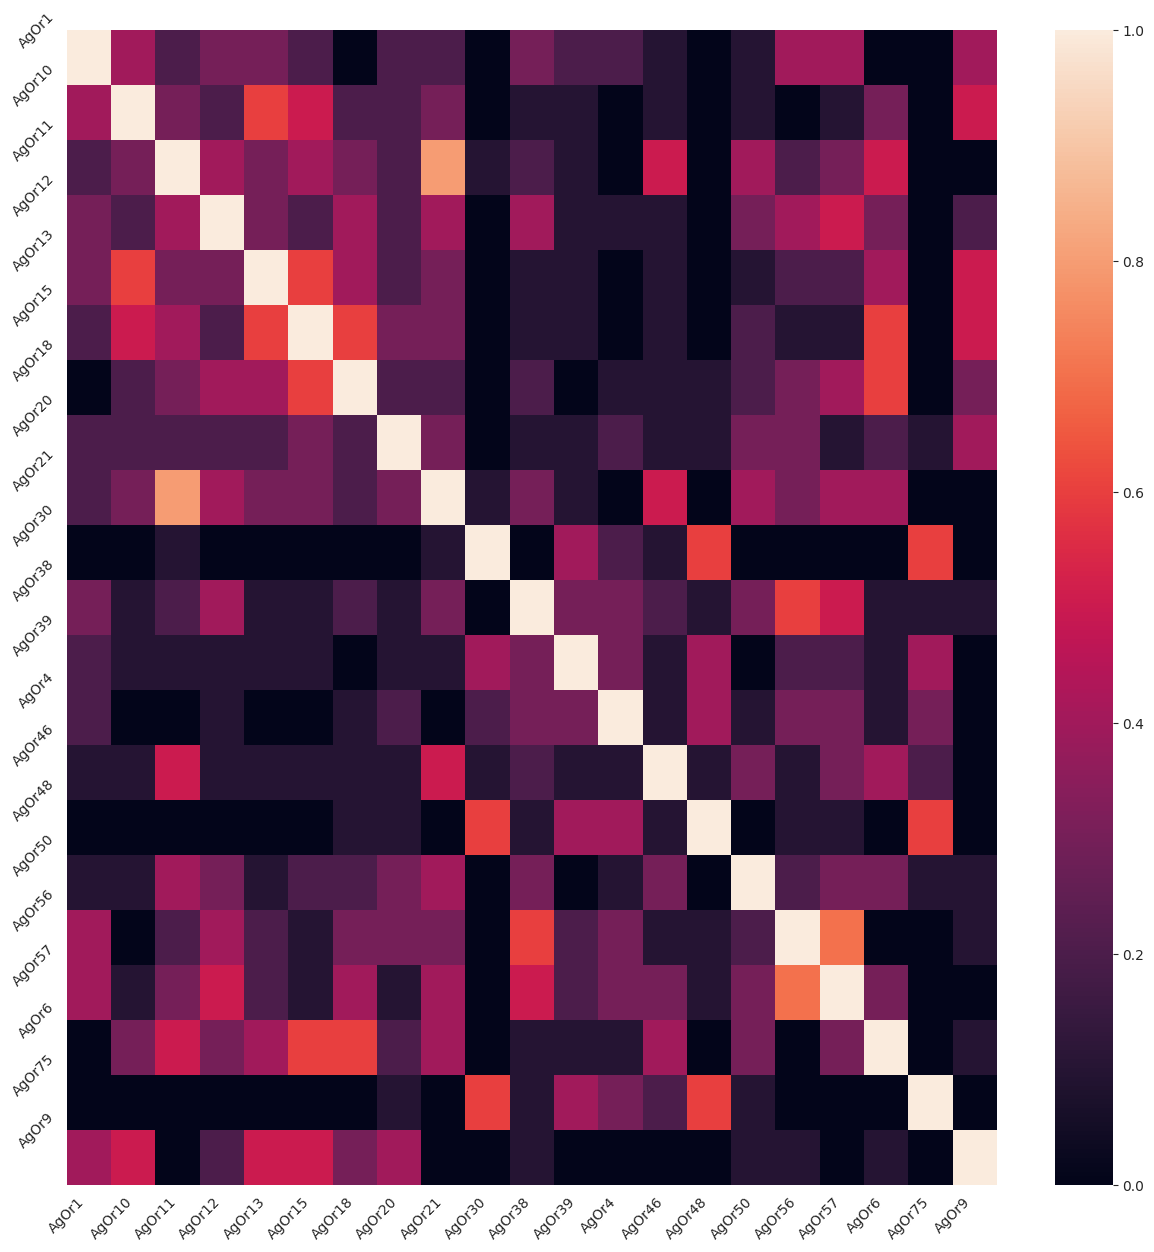

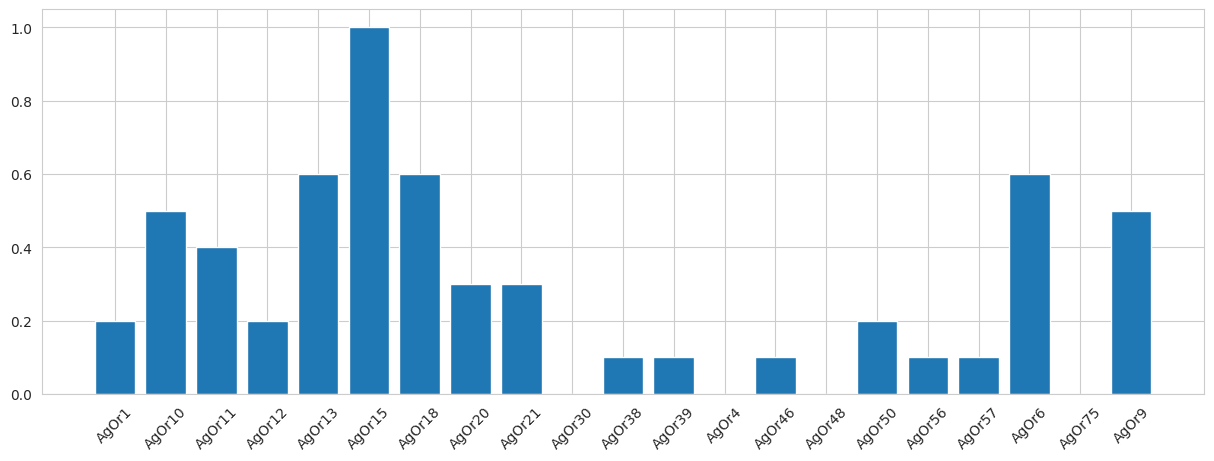

In [26]:
plt.figure(figsize=(15, 15))
sns.heatmap(corrs)
plt.xticks(np.arange(21), names, rotation=45)
plt.yticks(np.arange(21), names, rotation=45)
plt.show()

plt.figure(figsize=(15, 5))
plt.bar(names, corrs[5])
plt.xticks(rotation=45)
plt.show()

In [44]:
raw_df

,RECEPTOR,odorant,SMILES,output,Protein sequence
0,AgOr1,ammonia,N,-0.361859,MKLNKLNPRWDAYDRRDSFWLQLLCLKYLGLWPPEDTDQATRNRYI...
1,AgOr2,ammonia,N,-0.312210,MLIEECPIIGVNVRVWLFWSYLRRPRLSRFLVGCIPVAVLNVFQFL...
2,AgOr3,ammonia,N,-0.337035,MVLPKLKDETAVMPFLLRIQTIAGLWGDRSQRYRFYLIFSYFCAMV...
3,AgOr4,ammonia,N,-0.312210,MKFELFQKYSSPDTVLSFVLRLLHIVGMNGTGFRSRIRVGGIFLFY...
4,AgOr5,ammonia,N,-0.287386,MVLPKLSEPYAVMPLLLRLQRFVGLWGERRYRYKFRLAFLSFCLLV...
...,...,...,...,...,...
5495,AgOr66,5α-androsten-3α-ol,C[C@]12CC[C@@H](O)C[C@@H]1CC[C@@H]1[C@@H]2CC[C...,-0.535630,MEASEKFSQFERYIRTLCNIIGFDVMTETWKKSYRTYISIFLCSQY...
5496,AgOr67,5α-androsten-3α-ol,C[C@]12CC[C@@H](O)C[C@@H]1CC[C@@H]1[C@@H]2CC[C...,-0.361859,MEASEKFCQFERYLRTLCKIIGFDVMTETWKKSYQTYMSILLCSQY...
5497,AgOr73,5α-androsten-3α-ol,C[C@]12CC[C@@H](O)C[C@@H]1CC[C@@H]1[C@@H]2CC[C...,0.109805,MANVEEFRKLMKSLIVCSKVAGVEMWTAPGKLKPASYYLSFHITVY...
5498,AgOr75,5α-androsten-3α-ol,C[C@]12CC[C@@H](O)C[C@@H]1CC[C@@H]1[C@@H]2CC[C...,-0.337035,MTVVHRIVSFGYNLLQRHFNVGHPTEQFFLLRCLDVVSPAMLLQRP...


SignificanceResult(statistic=np.float64(0.7735847469839804), pvalue=np.float64(3.944717576524782e-23))


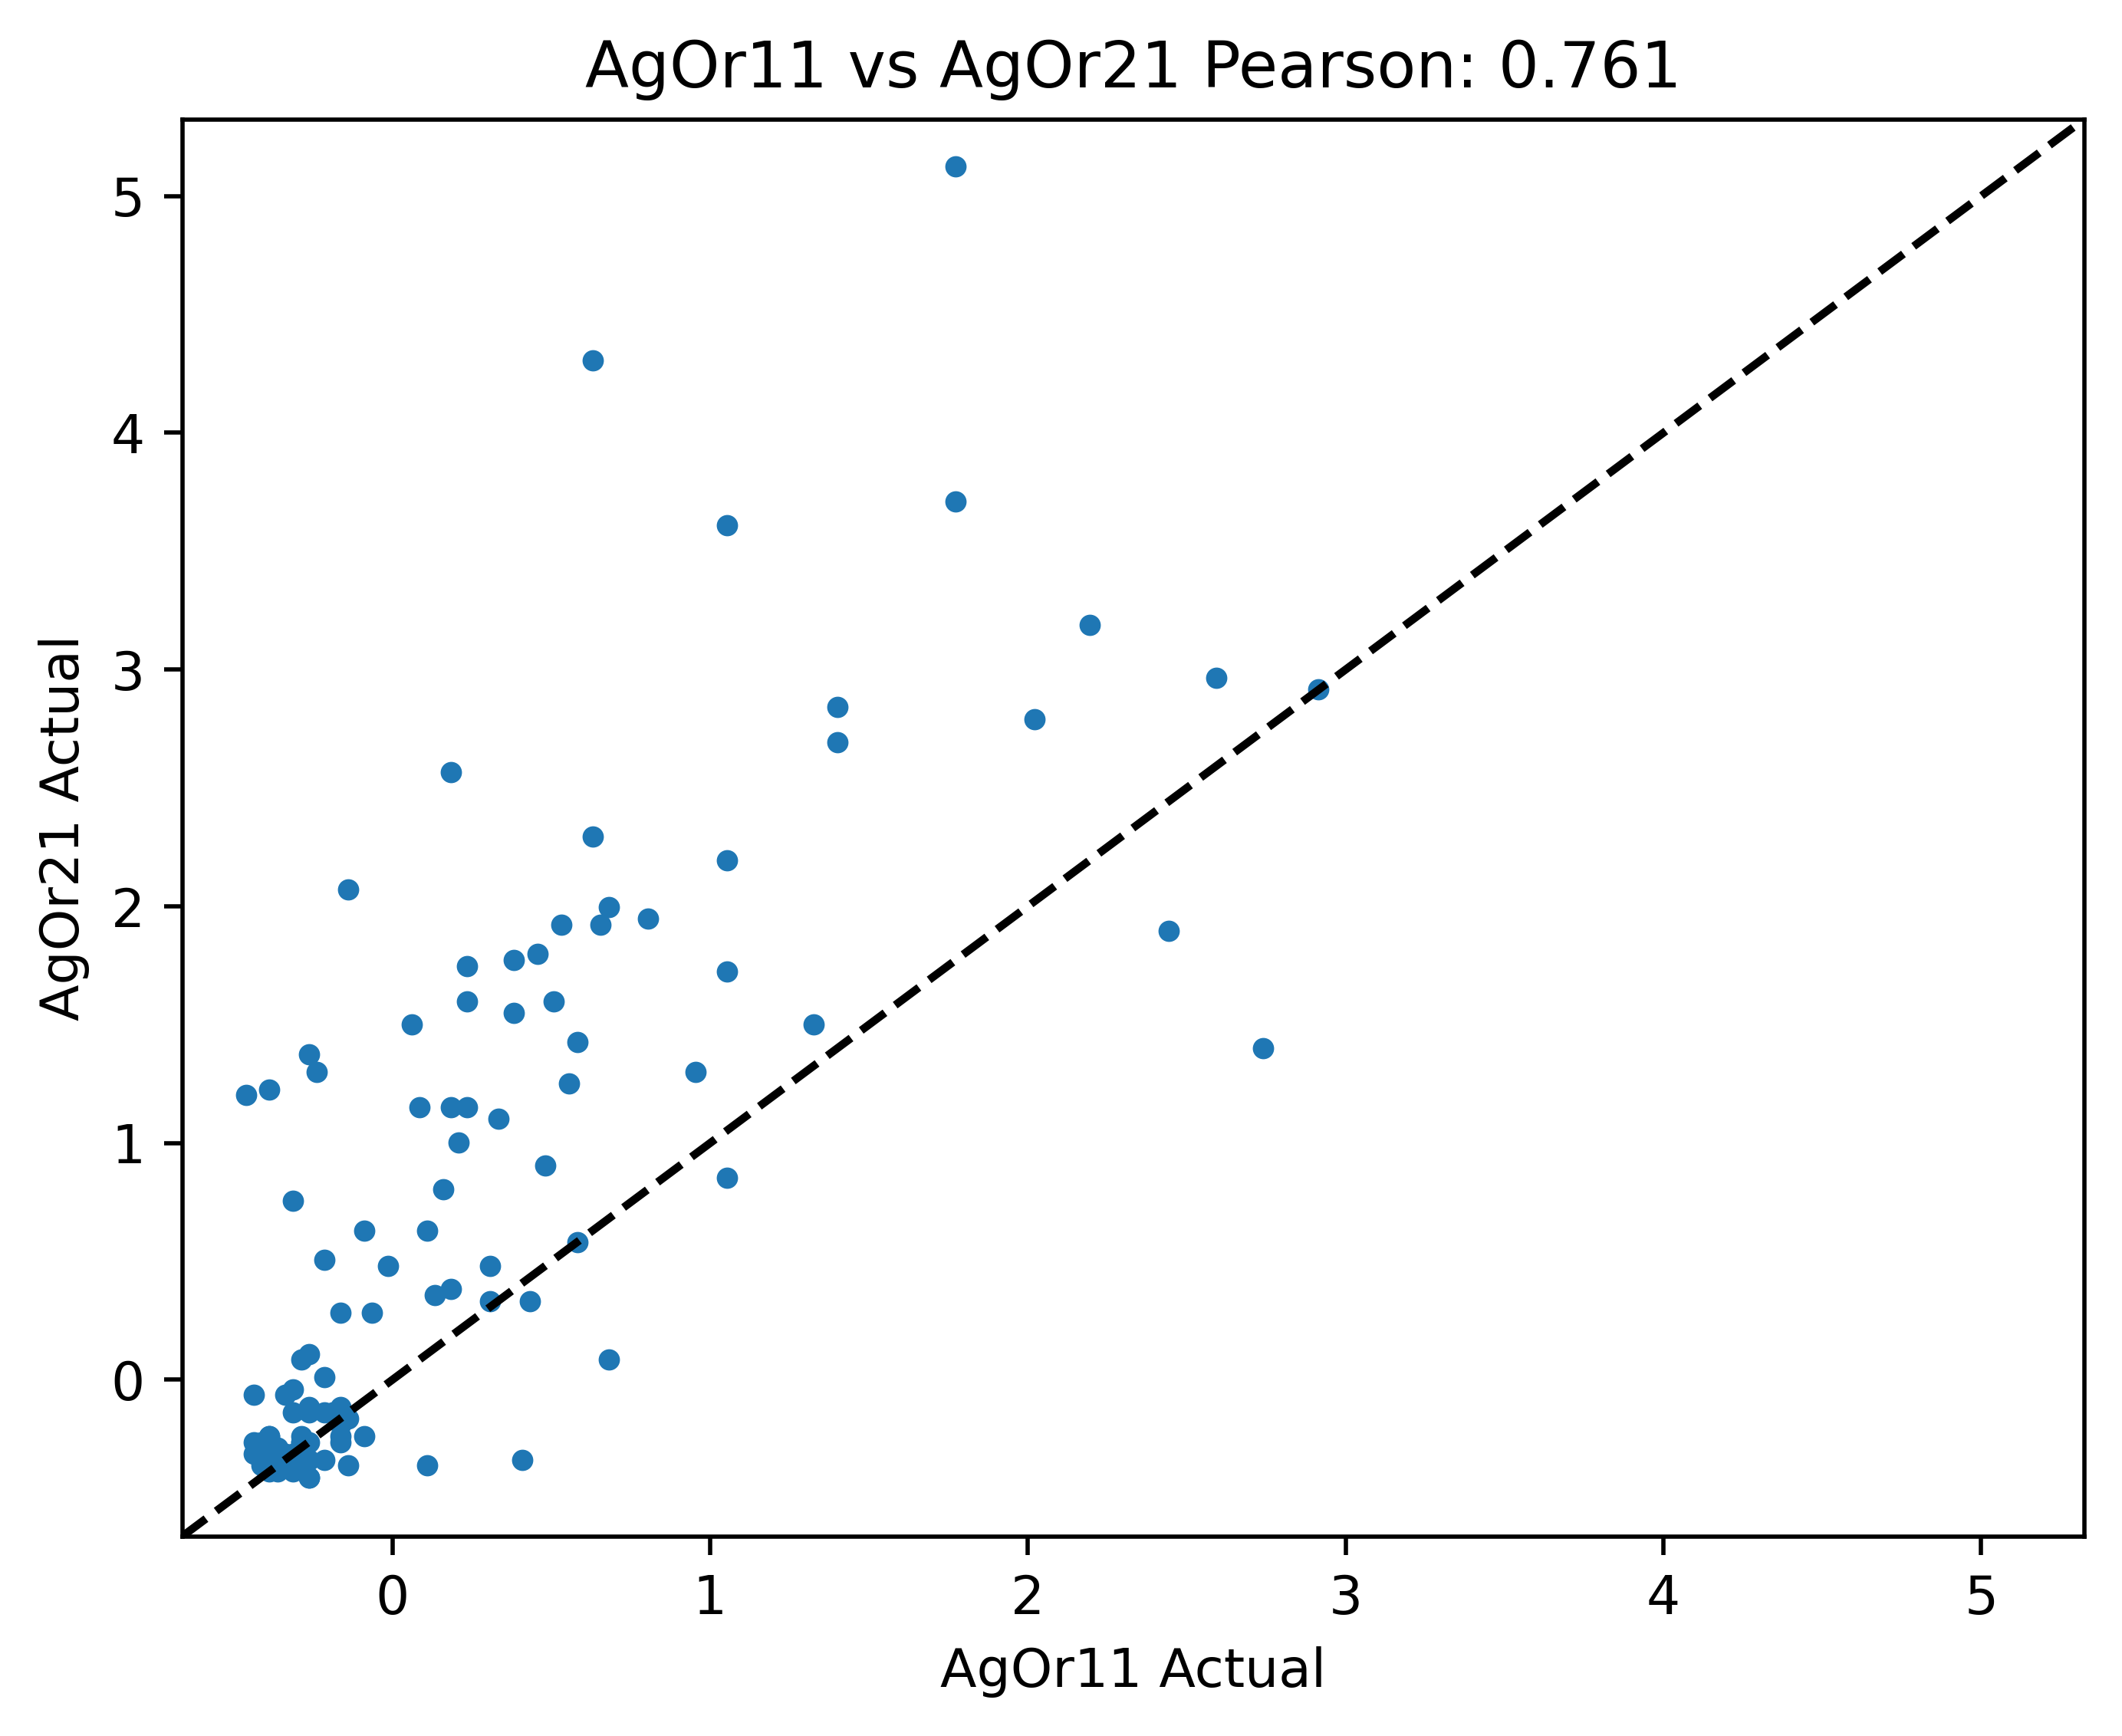

PearsonRResult(statistic=np.float64(0.760610319651033), pvalue=np.float64(5.466855978413607e-22))


In [50]:
raw_df = pd.read_csv('data/CC/raw/CC_reformat_z.csv')
receptor1 = 'AgOr11'
receptor2 = 'AgOr21'
col = 'output'

receptor1_df = raw_df[raw_df['RECEPTOR'] == receptor1]
receptor2_df = raw_df[raw_df['RECEPTOR'] == receptor2]
plt.figure(dpi=500)
plt.scatter(receptor1_df[col], receptor2_df[col], marker='.')
max_val = max(np.max(receptor1_df[col]), np.max(receptor2_df[col])) + 0.2
min_val = min(np.min(receptor1_df[col]), np.min(receptor2_df[col])) - 0.2
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.axline((0, 0), slope=1, color='k', linestyle='--')
plt.xlabel(f'{receptor1} Actual')
plt.ylabel(f'{receptor2} Actual')
corr = pearsonr(receptor1_df[col], receptor2_df[col])
print(spearmanr(receptor1_df[col], receptor2_df[col]))
plt.title(f'{receptor1} vs {receptor2} Pearson: {corr[0]:.3f}')
plt.show()
print(corr)

In [34]:
raw_df = pd.read_csv('data/CC/raw/CC_reformat_z.csv')

Text(0.5, 1.0, 'AgOr15')

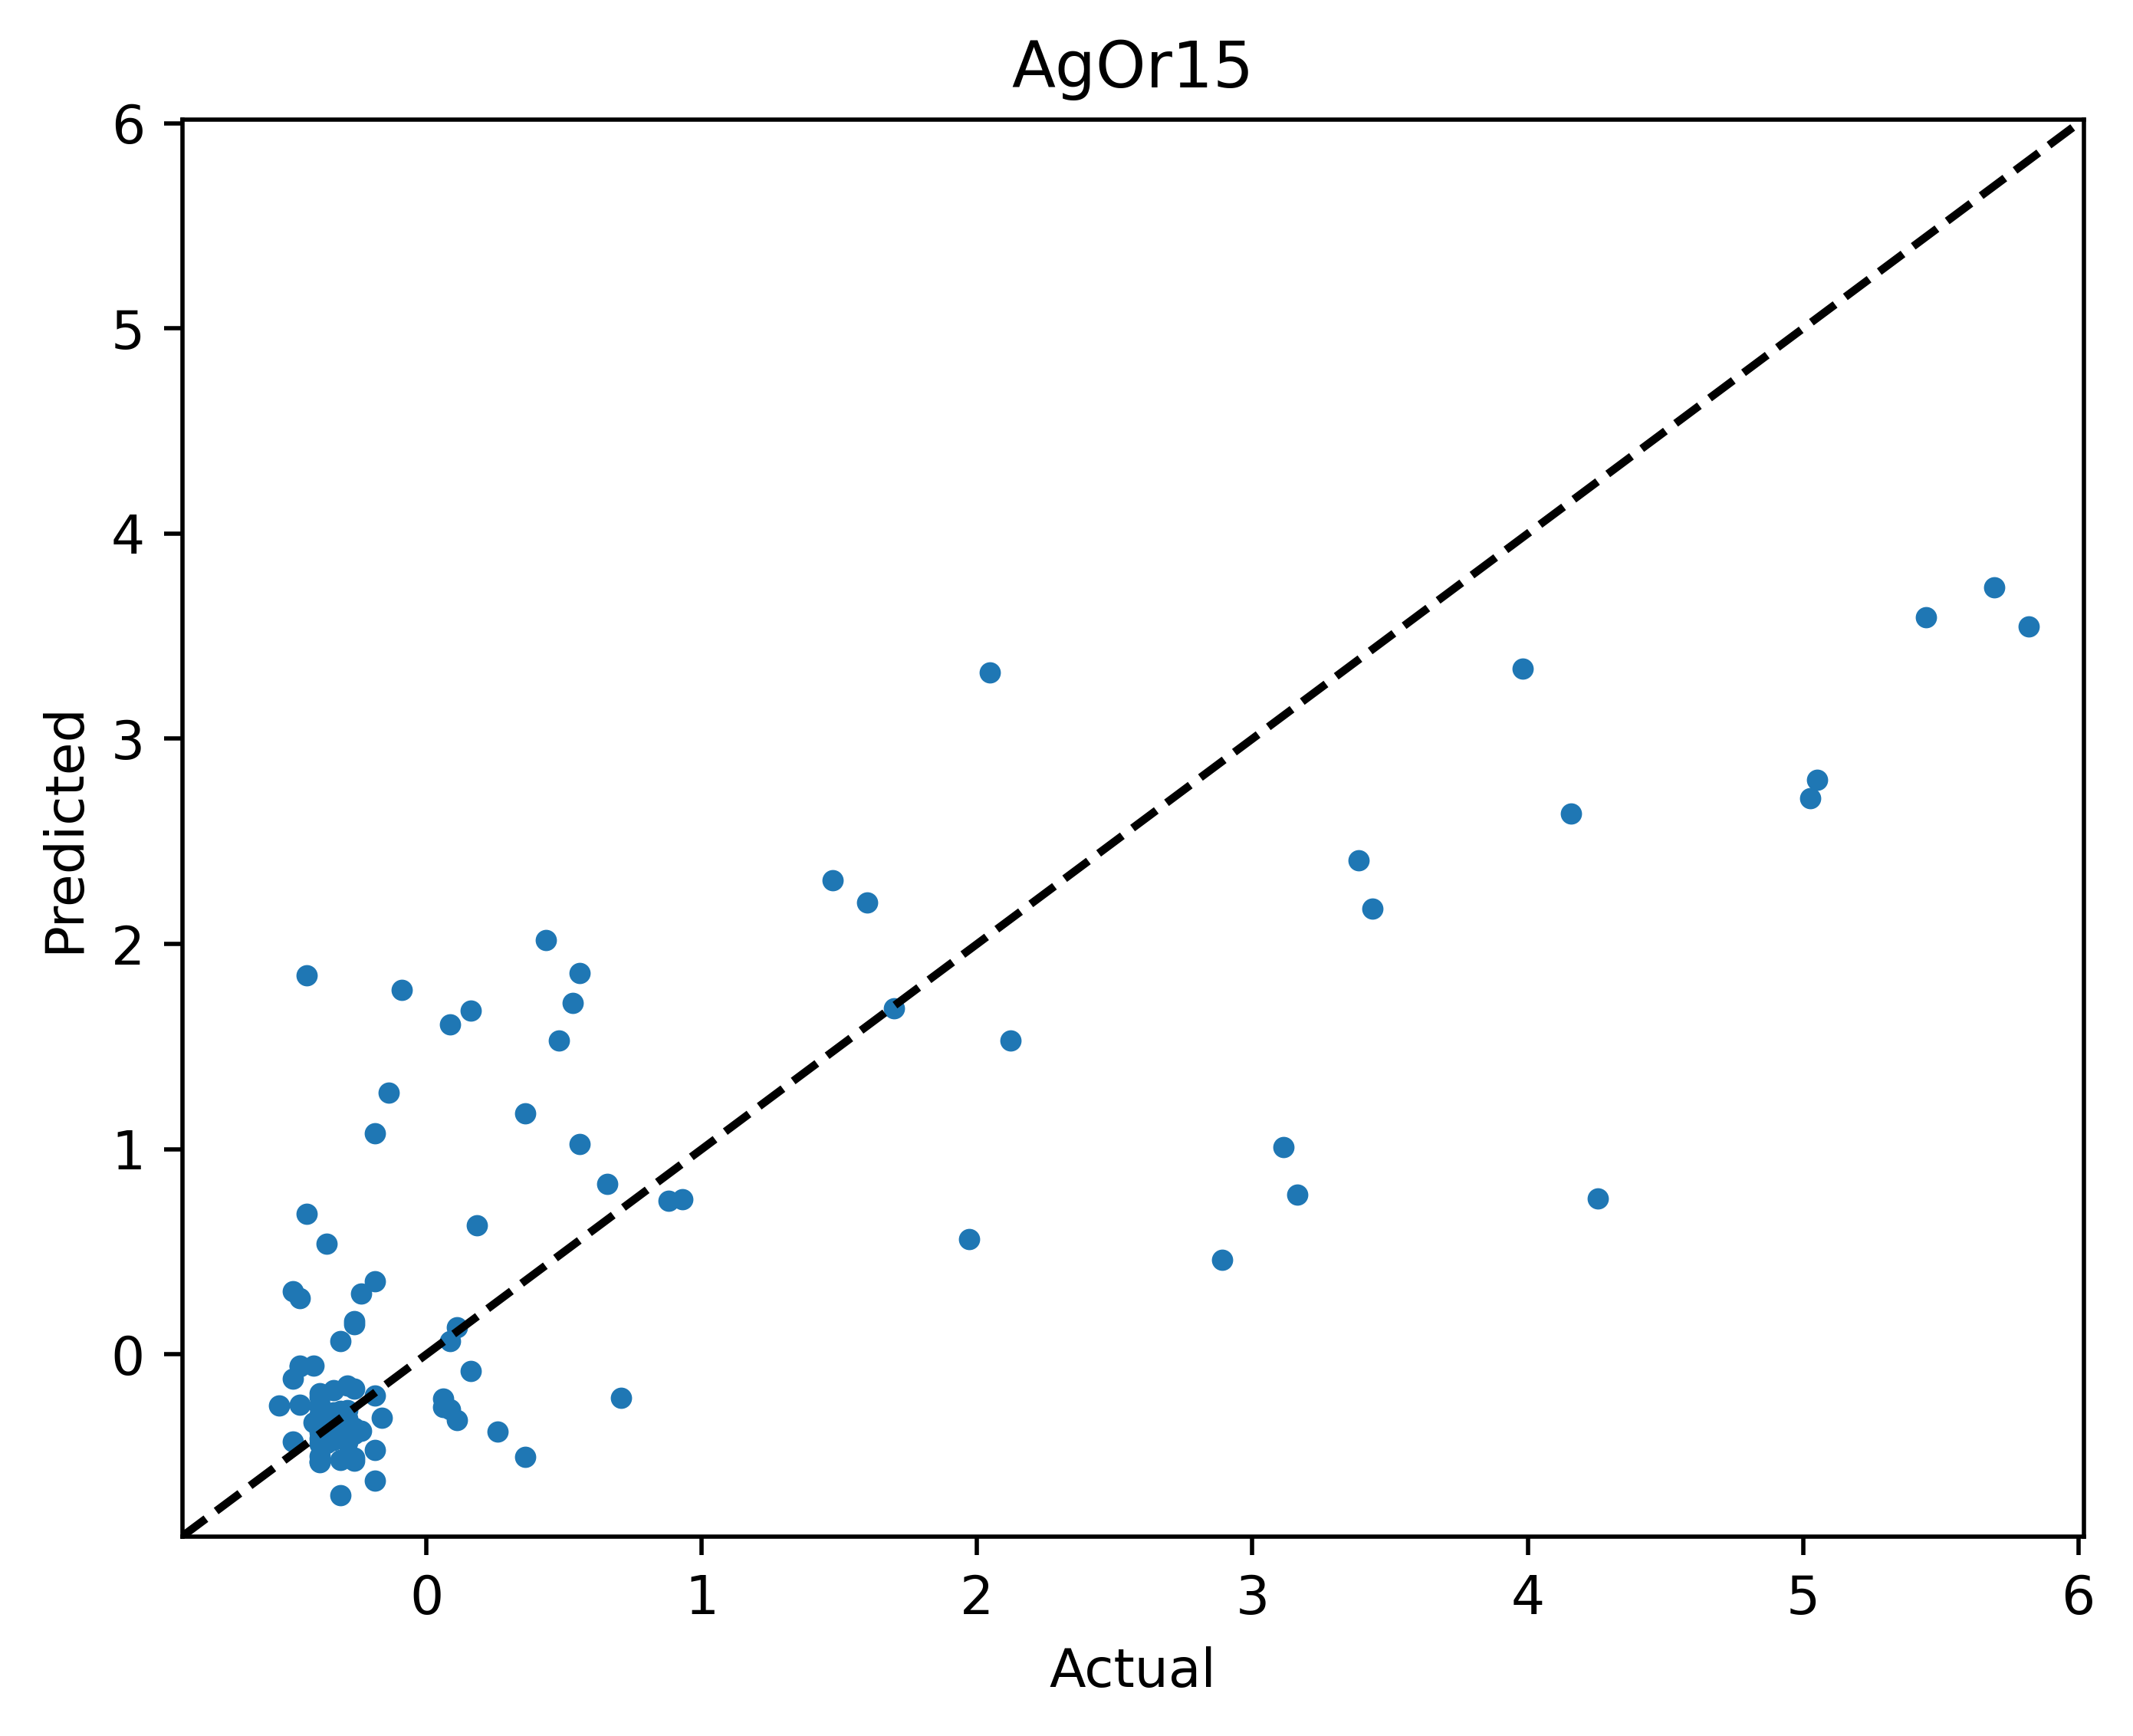

In [73]:
receptor = 'AgOr15'
agor10_df = df[df['RECEPTOR'] == receptor]
plt.figure(dpi=500)
plt.scatter(agor10_df['output'], agor10_df['prediction'], marker='.')
max_val = max(np.max(agor10_df['output']), np.max(agor10_df['prediction'])) + 0.2
min_val = min(np.min(agor10_df['output']), np.min(agor10_df['prediction'])) - 0.2
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.axline((0, 0), slope=1, color='k', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(receptor)

Text(0.5, 1.0, 'AgOr12')

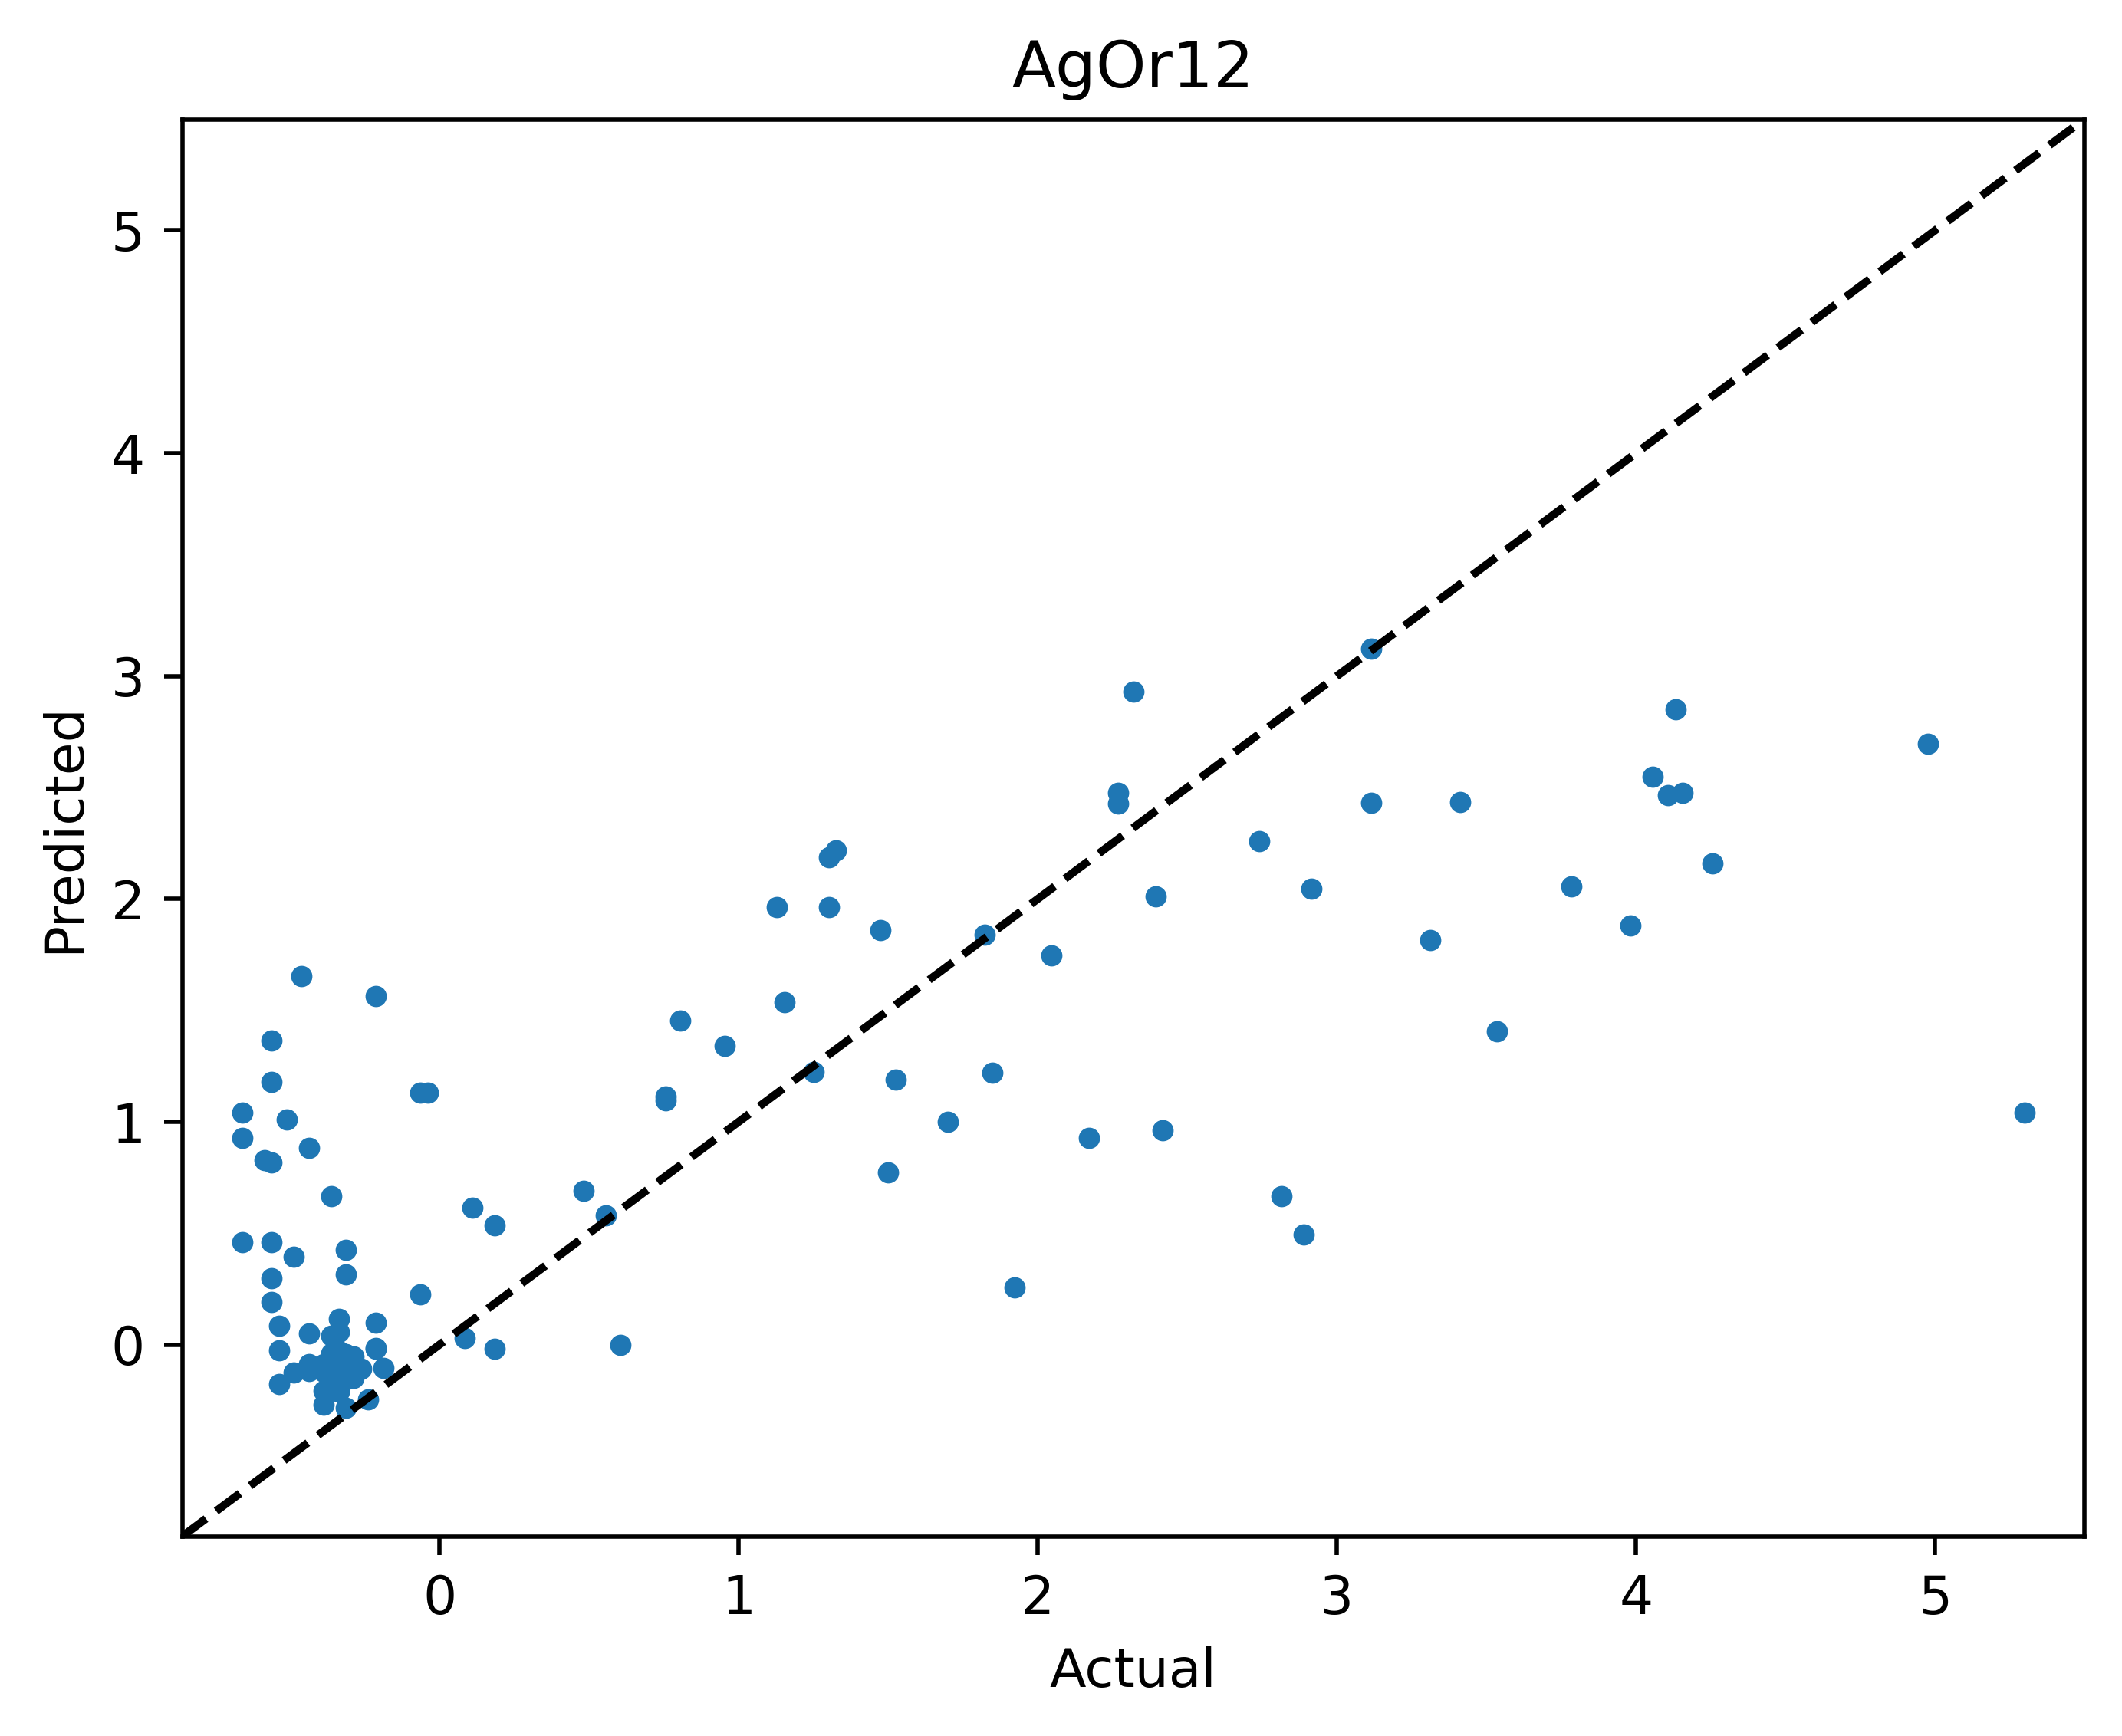

In [76]:
receptor = 'AgOr12'
agor10_df = df[df['RECEPTOR'] == receptor]
plt.figure(dpi=500)
plt.scatter(agor10_df['output'], agor10_df['prediction'], marker='.')
max_val = max(np.max(agor10_df['output']), np.max(agor10_df['prediction'])) + 0.2
min_val = min(np.min(agor10_df['output']), np.min(agor10_df['prediction'])) - 0.2
plt.xlim(min_val, max_val)
plt.ylim(min_val, max_val)
plt.axline((0, 0), slope=1, color='k', linestyle='--')
plt.xlabel('Actual')
plt.ylabel('Predicted')
plt.title(receptor)

# Baseline

In [5]:
from Bio import Align

In [6]:
blosum62 = Align.substitution_matrices.load("BLOSUM62")

aligner = Align.PairwiseAligner()
aligner.substitution_matrix = blosum62
aligner.open_gap_score = -10
aligner.extend_gap_score = -0.5
aligner.mode = "global"

def score_alignment(alignment, matrix):
    """Return (% identity, % similarity) over the aligned columns.
    identity: exact residue match. similarity: identical OR positive BLOSUM62 score."""
    a, b = alignment[0], alignment[1]
    ident = sim = 0
    for x, y in zip(a, b):
        if x == "-" or y == "-":
            continue
        if x == y:
            ident += 1
            sim += 1
        elif matrix[x, y] > 0:
            sim += 1
    L = len(a)
    return 100.0 * ident / L, 100.0 * sim / L


def all_vs_all(seqs):
    """Return (identity_matrix, similarity_matrix) over all pairs."""
    n = len(seqs)
    pid = np.zeros((n, n))
    psim = np.zeros((n, n))
    for i in range(n):
        pid[i, i] = psim[i, i] = 100.0
        for j in range(i + 1, n):
            aln = aligner.align(seqs[i], seqs[j])[0]
            ident, sim = score_alignment(aln, blosum62)
            pid[i, j] = pid[j, i] = ident
            psim[i, j] = psim[j, i] = sim
    return pid, psim

In [7]:
# Get sequence similarity
receptor_names = df_filtered['RECEPTOR'].unique()
sequences = df_filtered['Protein sequence'].unique()
pid, psim = all_vs_all(sequences)

## Baseline: Average

0.38095238095238093


/scratch/6832757.1.p-int/ipykernel_1901577/3895749279.py:5: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: topk_overlap(g['output'], g['avg_baseline'], k=10))


(0.0, 1.0)

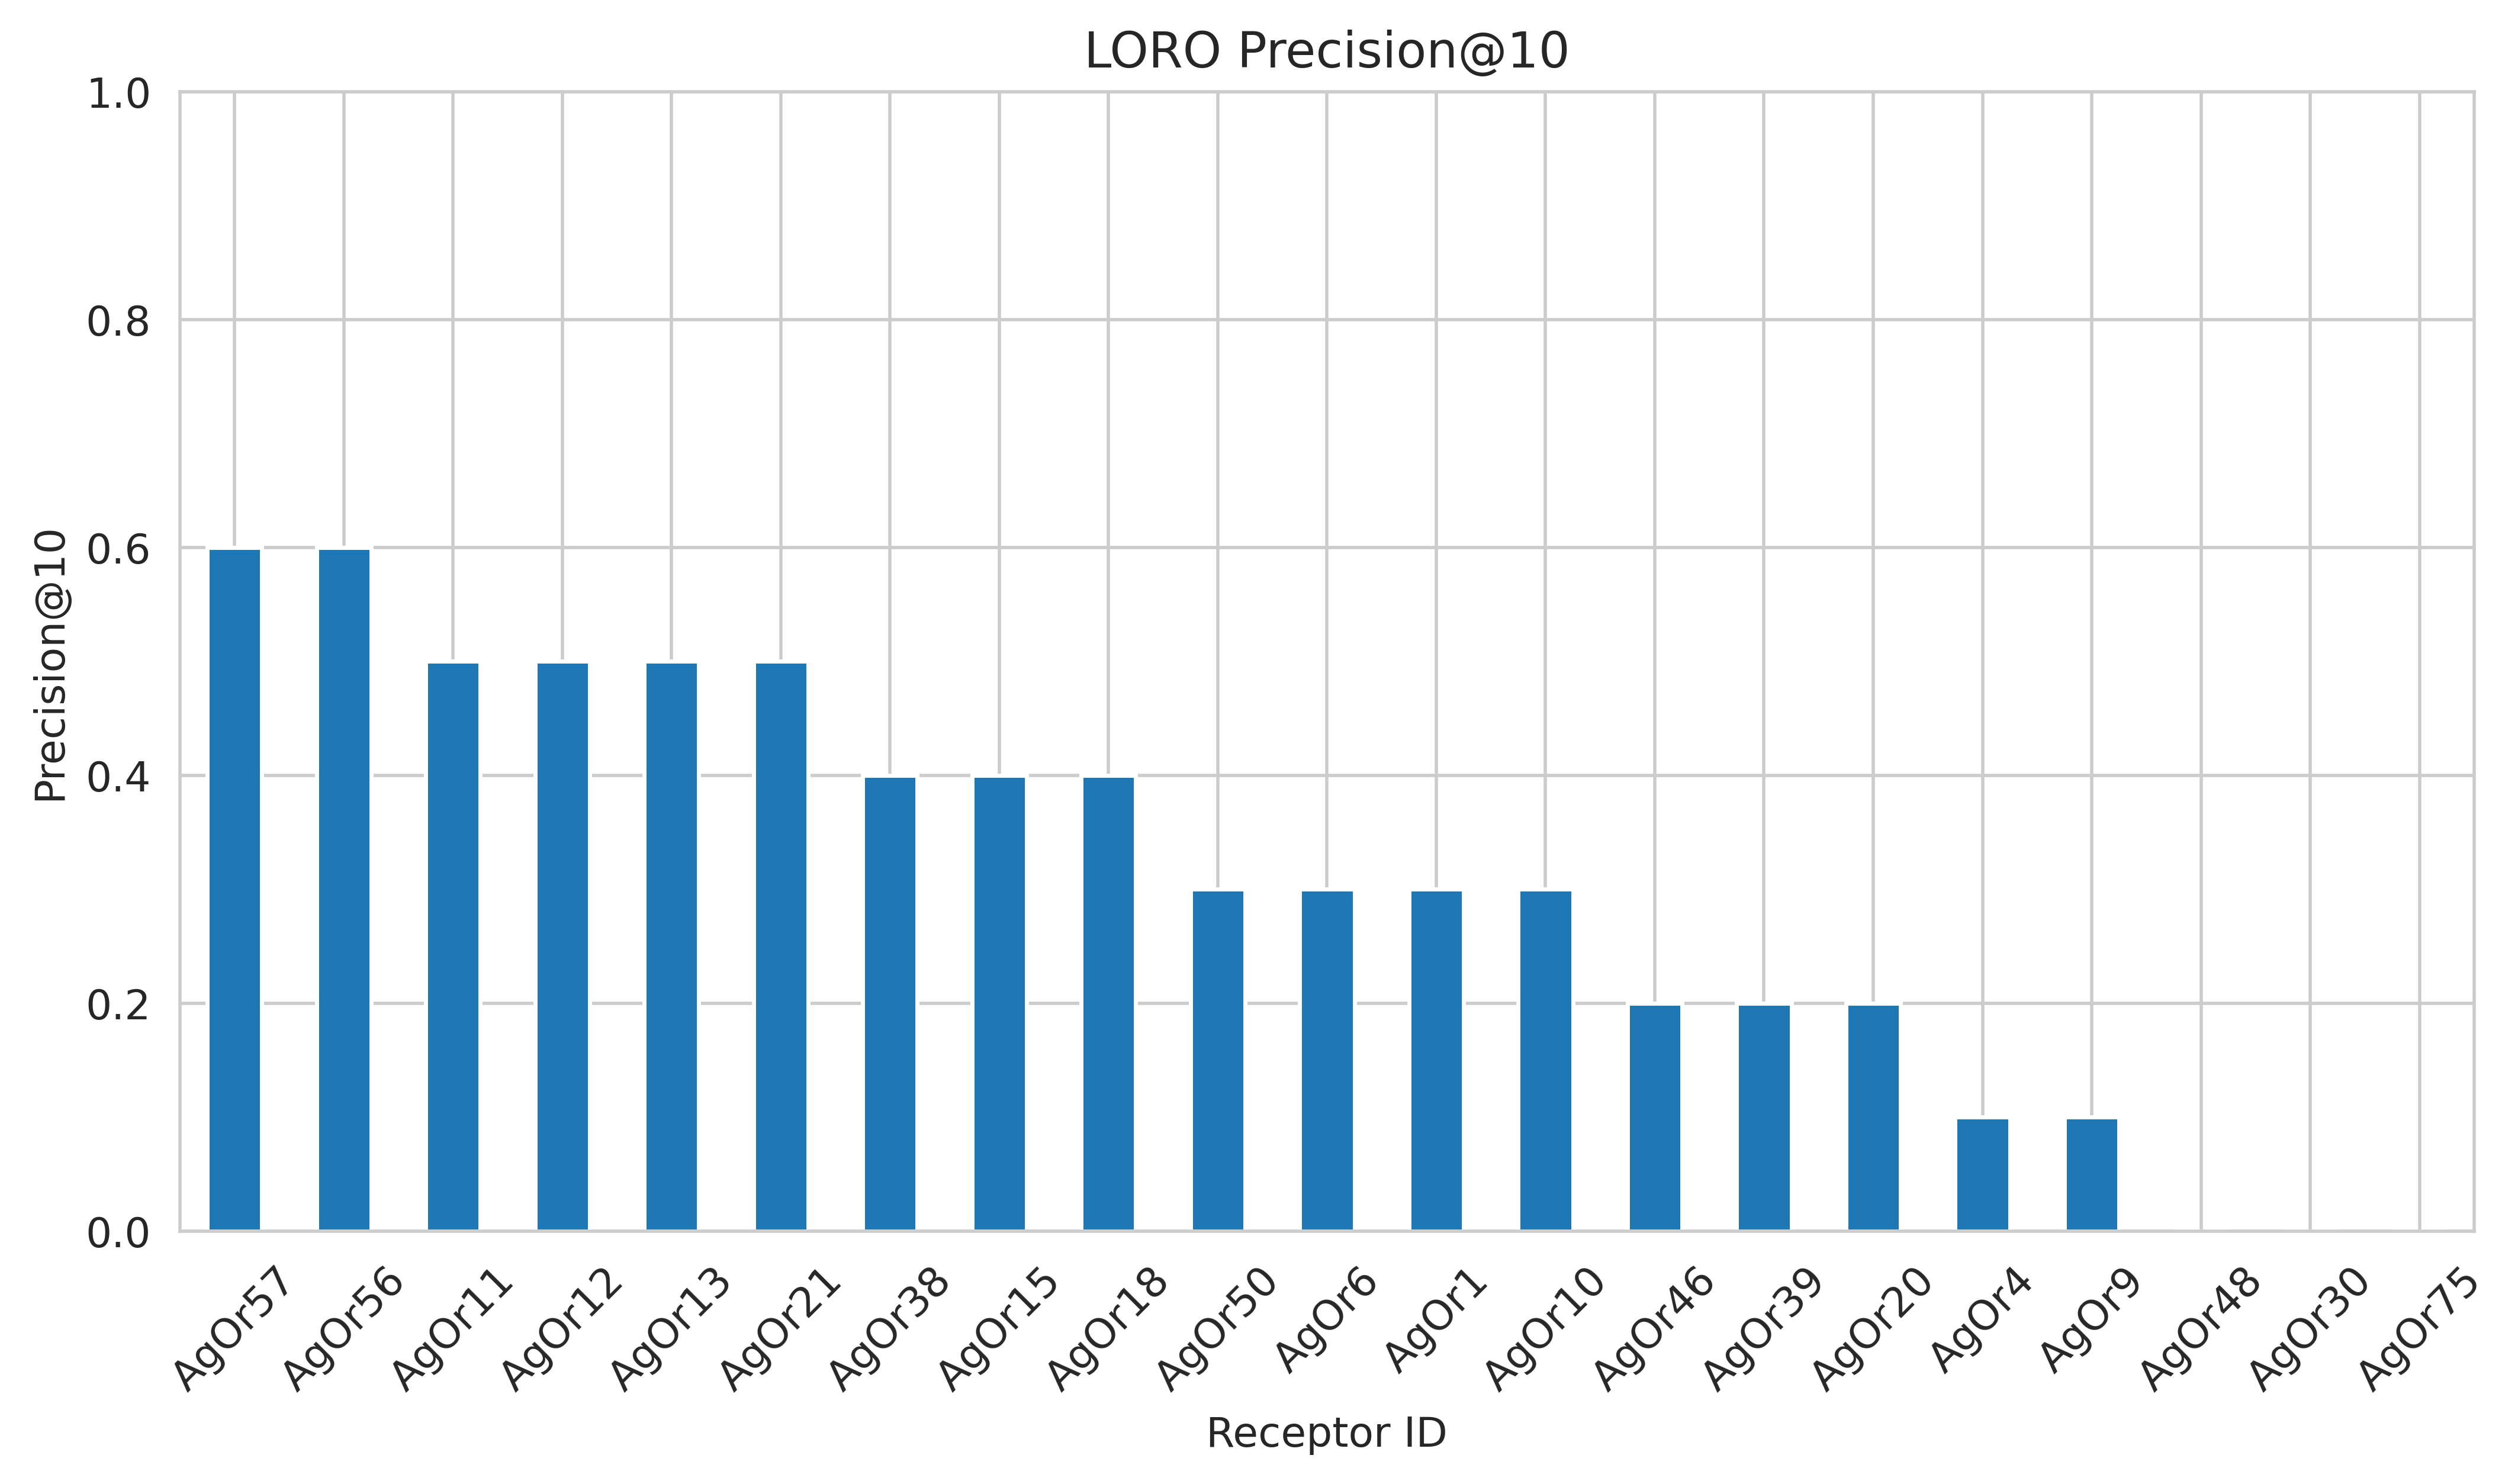

In [12]:
g = df_filtered.groupby('odorant')['output']
df_filtered['avg_baseline'] = (g.transform('sum') - df_filtered['output']) / (g.transform('size') - 1)

avg_baseline_topk = (df_filtered.groupby('RECEPTOR')
                       .apply(lambda g: topk_overlap(g['output'], g['avg_baseline'], k=10))
                       .sort_values(ascending=False))

print(topk.mean())
fig, ax = plt.subplots(figsize=(10,5), dpi=500)
plt.grid(axis='y')
avg_baseline_topk.plot.bar(ax=ax, rot=45)
ax.set_ylabel('Precision@10')
ax.set_xlabel('Receptor ID')
ax.set_title('LORO Precision@10')
ax.set_ylim(0, 1.0)


<Axes: xlabel='RECEPTOR'>

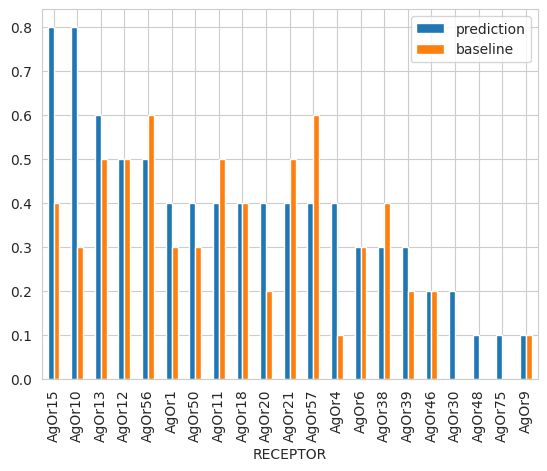

In [ ]:
compare = pd.DataFrame({'LORAX': topk, 'Chemical Average baseline': avg_baseline_topk}).sort_values('LORAX', ascending=False)
compare.plot.bar()

## Baseline: Top One Nearest Neighborhood

In [9]:
sim = psim.copy()
np.fill_diagonal(sim, -np.inf)          # so a receptor can't be its own neighbor
nn_idx = sim.argmax(axis=1)             # index of best neighbor for each receptor

# map row/col indices -> receptor names
nn_receptor = dict(zip(receptor_names, receptor_names[nn_idx]))

df_filtered['nn_receptor'] = df_filtered['RECEPTOR'].map(nn_receptor)

# a copy of the outputs, relabeled so its receptor column is the *neighbor* key
neighbor_vals = (df_filtered[['RECEPTOR', 'odorant', 'output']]
                 .rename(columns={'RECEPTOR': 'nn_receptor', 'output': 'nn_baseline'}))

df_filtered = df_filtered.merge(neighbor_vals, on=['nn_receptor', 'odorant'], how='left')


0.3428571428571428


/scratch/6870247.1.p-int/ipykernel_2226038/1980276520.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: topk_overlap(g['output'], g['nn_baseline'], k=10))


(0.0, 1.0)

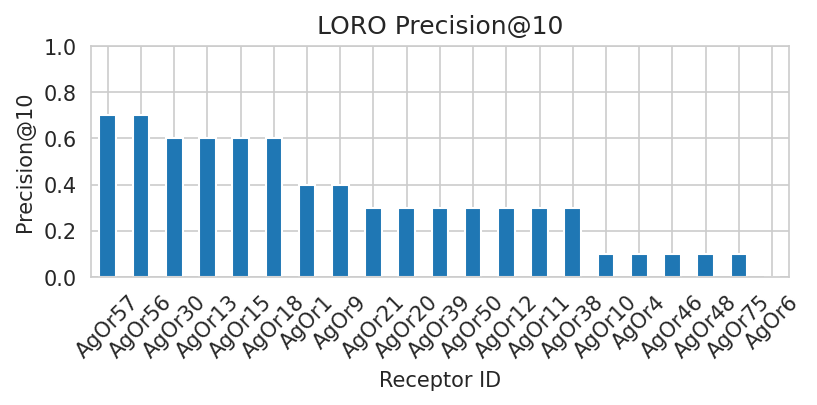

In [48]:
nn_baseline_topk = (df_filtered.groupby('RECEPTOR')
                       .apply(lambda g: topk_overlap(g['output'], g['nn_baseline'], k=10))
                       .sort_values(ascending=False))

print(nn_baseline_topk.mean())
fig, ax = plt.subplots(figsize=(6,2), dpi=150)
plt.grid(axis='y')
nn_baseline_topk.plot.bar(ax=ax, rot=45)
ax.set_ylabel('Precision@10')
ax.set_xlabel('Receptor ID')
ax.set_title('LORO Precision@10')
ax.set_ylim(0, 1.0)

Text(0, 0.5, 'Precision@10')

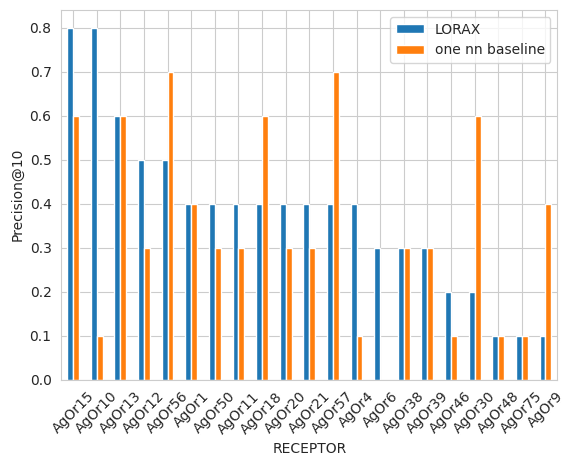

In [85]:
compare = pd.DataFrame({'LORAX': topk, 'one nn baseline': nn_baseline_topk}).sort_values('LORAX', ascending=False)
compare.plot.bar(rot=45)
plt.ylabel('Precision@10')

<Axes: xlabel='RECEPTOR'>

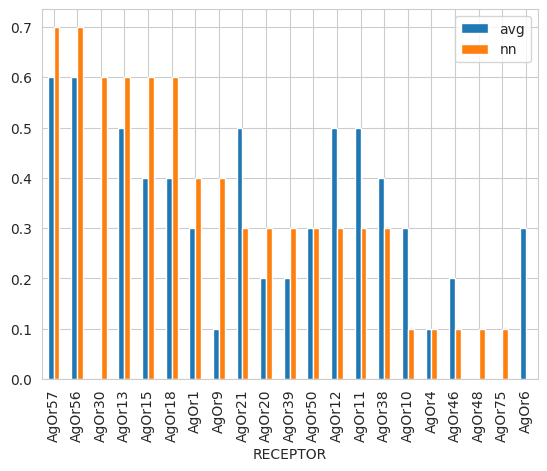

In [22]:
compare = pd.DataFrame({'avg': avg_baseline_topk, 'nn': nn_baseline_topk}).sort_values('nn', ascending=False)
compare.plot.bar()

# Baseline: Softmax KNN

In [79]:
from scipy.special import softmax
groundtruths = np.array([df_filtered[df_filtered['RECEPTOR'] == r]['output'] for r in df_filtered['RECEPTOR'].unique()])
psim[np.diag_indices(21)] = -np.inf
#print(psim)
temp = 10
weights = softmax(psim/temp, axis=1)
softmax_baseline = weights @ groundtruths
df_filtered['softmax_baseline'] = softmax_baseline.reshape(-1)


0.3142857142857143


/scratch/6870247.1.p-int/ipykernel_2226038/3230685533.py:2: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: topk_overlap(g['output'], g['softmax_baseline'], k=10))


(0.0, 1.0)

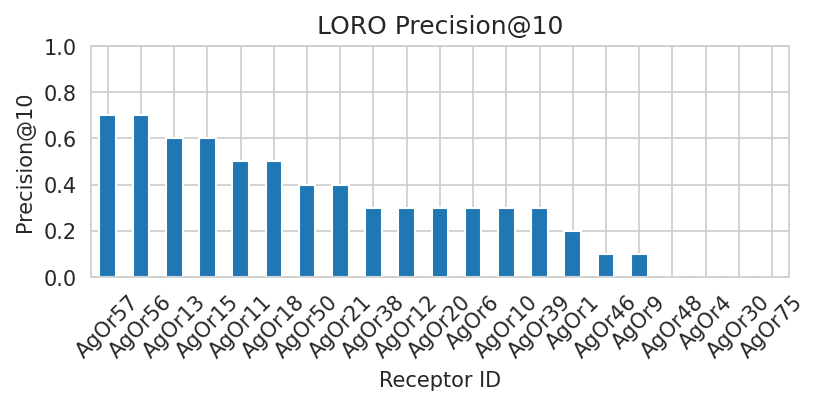

In [80]:
softmax_baseline_topk = (df_filtered.groupby('RECEPTOR')
                       .apply(lambda g: topk_overlap(g['output'], g['softmax_baseline'], k=10))
                       .sort_values(ascending=False))

print(softmax_baseline_topk.mean())
fig, ax = plt.subplots(figsize=(6,2), dpi=150)
plt.grid(axis='y')
softmax_baseline_topk.plot.bar(ax=ax, rot=45)
ax.set_ylabel('Precision@10')
ax.set_xlabel('Receptor ID')
ax.set_title('LORO Precision@10')
ax.set_ylim(0, 1.0)

<Axes: xlabel='RECEPTOR'>

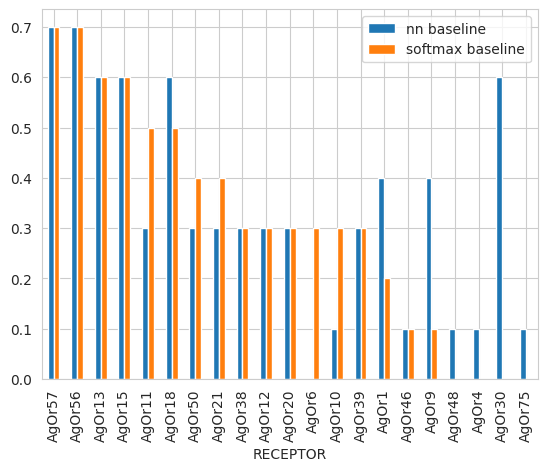

In [81]:
compare = pd.DataFrame({'nn baseline': nn_baseline_topk, 'softmax baseline': softmax_baseline_topk}).sort_values('softmax baseline', ascending=False)
compare.plot.bar()